# HDBSCAN Track Clustering

Use this notebook to discover meaningful groups of matched Rekordbox tracks. The cluster assignments are intended as an exploratory foundation for:

- Style Profile Modeling
- Cluster Expansion
- New Music Discovery
- Recommendation Engine Development

Scope for this first pass: only tracks with an accepted Spotify match and a complete DJ audio-analysis feature vector are clustered.

## Notebook Structure

This notebook now contains four HDBSCAN experiment paths:

1. A full-feature clustering pass using `cluster_selection_method="leaf"`.
2. A full-feature clustering pass using `cluster_selection_method="eom"`.
3. A composite-feature clustering pass using `cluster_selection_method="leaf"`.
4. A composite-feature clustering pass using `cluster_selection_method="eom"`.

The composite passes group correlated signals into musical dimensions such as `intensity`, `warmth`, `mixability`, and `vocal_presence`. Each experiment is kept separate so parameter and feature-representation changes can be compared without deleting or overwriting the original work.

## Setup

The clustering feature set is intentionally explicit. `rhythm.bpm` is preferred over the original Rekordbox BPM when available, with `rekordbox_tracks.bpm` used as a fallback.

In [1]:
from pathlib import Path
import os
import sqlite3

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if load_dotenv:
    load_dotenv(PROJECT_ROOT / ".env")

db_path = Path(os.getenv("SQLITE_DB_PATH", "data/rekordbox_tracks.sqlite3"))
if not db_path.is_absolute():
    db_path = PROJECT_ROOT / db_path

EXPORT_DIR = PROJECT_ROOT / "data" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
XDG_CACHE_HOME = PROJECT_ROOT / ".cache"
XDG_CACHE_HOME.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_HOME))

FEATURE_COLUMNS = [
    "bpm",
    "popularity",
    "danceability",
    "energy",
    "speechiness",
    "valence",
    "chill",
    "aggressive",
    "hype",
    "dance_floor",
    "groove",
    "warmup",
    "peak_time",
    "blendability",
    "vocal_risk",
]

print(f"Project root: {PROJECT_ROOT}")
print(f"SQLite database: {db_path}")
print(f"Database exists: {db_path.exists()}")
print(f"Export directory: {EXPORT_DIR}")
print(f"Matplotlib cache: {MPLCONFIGDIR}")
print(f"Shared cache: {XDG_CACHE_HOME}")

Project root: /Users/zacurbiztondo/dj-library-helper
SQLite database: /Users/zacurbiztondo/dj-library-helper/data/rekordbox_tracks.sqlite3
Database exists: True
Export directory: /Users/zacurbiztondo/dj-library-helper/data/exports
Matplotlib cache: /Users/zacurbiztondo/dj-library-helper/.matplotlib-cache
Shared cache: /Users/zacurbiztondo/dj-library-helper/.cache


In [2]:
try:
    import numpy as np
    import pandas as pd
    from IPython.display import display
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    import hdbscan
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "Install notebook clustering dependencies first: "
        "pip install pandas numpy scikit-learn hdbscan matplotlib seaborn"
    ) from exc

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")

## Connect And Validate Source Tables

The notebook uses the local SQLite database created by the ingestion and enrichment scripts. Required tables are joined on `rekordbox_track_id`; the accepted match table is the row filter that keeps this pass to matched tracks only.

In [3]:
if not db_path.exists():
    raise FileNotFoundError(f"SQLite database not found: {db_path}")

conn = sqlite3.connect(db_path)
conn.row_factory = sqlite3.Row


def table_names():
    rows = conn.execute(
        """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
        """
    ).fetchall()
    return {row["name"] for row in rows}


def table_columns(table_name):
    return {
        row["name"]
        for row in conn.execute(f'PRAGMA table_info("{table_name}")').fetchall()
    }

required_tables = {
    "rekordbox_tracks",
    "rekordbox_spotify_matches",
    "spotify_tracks",
    "track_analysis",
    "rhythm",
    "score",
}
existing_tables = table_names()
missing_tables = sorted(required_tables - existing_tables)
if missing_tables:
    raise ValueError(
        "Missing required table(s): "
        + ", ".join(missing_tables)
        + ". Run Spotify and DJ audio-analysis enrichment before clustering."
    )

required_score_columns = set(FEATURE_COLUMNS) - {"bpm", "popularity"}
missing_score_columns = sorted(required_score_columns - table_columns("score"))
missing_track_analysis_columns = sorted({"popularity"} - table_columns("track_analysis"))
missing_rhythm_columns = sorted({"bpm"} - table_columns("rhythm"))
if missing_score_columns or missing_track_analysis_columns or missing_rhythm_columns:
    raise ValueError(
        "Missing required feature columns. "
        f"score={missing_score_columns}, "
        f"track_analysis={missing_track_analysis_columns}, "
        f"rhythm={missing_rhythm_columns}"
    )

row_counts = pd.DataFrame(
    [
        {
            "table": table,
            "rows": conn.execute(f'SELECT COUNT(*) AS count FROM "{table}"').fetchone()["count"],
        }
        for table in sorted(required_tables)
    ]
)
display(row_counts)

,table,rows
0,rekordbox_spotify_matches,209
1,rekordbox_tracks,317
2,rhythm,209
3,score,209
4,spotify_tracks,276
5,track_analysis,209


## Load Matched Track Feature Base

This query returns one row per accepted Rekordbox/Spotify match. Clustering later filters to complete feature rows, but this base keeps enough metadata to inspect cluster membership and export useful assignments.

In [4]:
matched_tracks_query = """
SELECT
    rb.rekordbox_track_id,
    rb.title AS rekordbox_title,
    rb.artist AS rekordbox_artist,
    rb.album AS rekordbox_album,
    rb.genre AS rekordbox_genre,
    rb.key AS rekordbox_key,
    rb.rating AS rekordbox_rating,
    rb.comments AS rekordbox_comments,
    rb.duration AS rekordbox_duration_seconds,
    rb.date_added,
    rb.file_path,
    rb.playlist_name,
    m.spotify_track_id,
    m.match_score,
    m.matched_at,
    st.title AS spotify_title,
    st.artist_names AS spotify_artist_names,
    st.album_name AS spotify_album_name,
    st.duration_ms AS spotify_duration_ms,
    st.spotify_url,
    ta.name AS analysis_name,
    COALESCE(r.bpm, rb.bpm) AS bpm,
    ta.popularity,
    s.danceability,
    s.energy,
    s.speechiness,
    s.valence,
    s.chill,
    s.aggressive,
    s.hype,
    s.dance_floor,
    s.groove,
    s.warmup,
    s.peak_time,
    s.blendability,
    s.vocal_risk
FROM rekordbox_spotify_matches m
JOIN rekordbox_tracks rb
    ON m.rekordbox_track_id = rb.rekordbox_track_id
LEFT JOIN spotify_tracks st
    ON m.spotify_track_id = st.spotify_track_id
LEFT JOIN track_analysis ta
    ON m.rekordbox_track_id = ta.rekordbox_track_id
LEFT JOIN rhythm r
    ON m.rekordbox_track_id = r.rekordbox_track_id
LEFT JOIN score s
    ON m.rekordbox_track_id = s.rekordbox_track_id
ORDER BY rb.rekordbox_track_id
"""

matched_tracks = pd.read_sql_query(matched_tracks_query, conn)
for column in FEATURE_COLUMNS:
    matched_tracks[column] = pd.to_numeric(matched_tracks[column], errors="coerce")

print(f"Matched tracks loaded: {len(matched_tracks):,}")
display(matched_tracks.head(20))

Matched tracks loaded: 209


,rekordbox_track_id,rekordbox_title,rekordbox_artist,rekordbox_album,rekordbox_genre,rekordbox_key,rekordbox_rating,rekordbox_comments,rekordbox_duration_seconds,date_added,file_path,playlist_name,spotify_track_id,match_score,matched_at,spotify_title,spotify_artist_names,spotify_album_name,spotify_duration_ms,spotify_url,analysis_name,bpm,popularity,danceability,energy,speechiness,valence,chill,aggressive,hype,dance_floor,groove,warmup,peak_time,blendability,vocal_risk
0,257614,baby again.. (original mix),"four tet, skrillex, fred again..",Baby again..,Bass House,Gm,0,,319.0,2024-11-09 00:00:00.000000,Users/zacurbiztondo/Desktop/DJ-Music/Baby agai...,Z,4zlbKky2yA657Sk5rekZoR,0.8333,2026-06-13 04:34:56,Baby again..,"Fred again.., Skrillex, Four Tet",Baby again..,319963,https://open.spotify.com/track/4zlbKky2yA657Sk...,Baby again..,126.983,61,0.847,0.724,0.047,0.326,0.001,0.721,0.833,0.792,0.879,0.300,0.761,0.504,0.427
1,549049,go dj [explicit],lil wayne,Tha Carter [Explicit],Rap & Hip-Hop,Em,0,Amazon.com Song ID: 202366200,281.0,2024-11-09 00:00:00.000000,Users/zacurbiztondo/Desktop/DJ-Music/Rap/Go DJ...,Z,2x2iWUo1PYncvoUQO8M94J,0.9690,2026-06-13 05:15:06,Go DJ,Lil Wayne,Tha Carter,281826,https://open.spotify.com/track/2x2iWUo1PYncvoU...,Go DJ,157.955,12,0.736,0.792,0.146,0.699,0.013,0.743,0.860,0.761,0.771,0.305,0.775,0.446,0.488
2,786655,murdah (isoxo remix),knock2,niteharts,Trap / Future Bass,Dm,0,,172.0,2026-03-31 00:00:00.000000,Users/zacurbiztondo/Downloads/beatport_tracks_...,Z,1wecjDqjR28ENc6G4oGIBh,0.9000,2026-06-13 05:15:08,murdah (ISOxo Remix),"Knock2, ISOxo",niteharts,172137,https://open.spotify.com/track/1wecjDqjR28ENc6...,murdah (ISOxo Remix),144.937,45,0.592,0.986,0.105,0.182,0.001,0.946,0.981,0.769,0.683,0.218,0.868,0.432,0.463
3,1112161,on my mind (original mix),"diplo, sidepiece",On My Mind,Bass House,Gm,0,,189.0,2024-11-09 00:00:00.000000,Users/zacurbiztondo/Desktop/DJ-Music/On My Min...,Z,54hA0ldJYyT1huGfSeOjdQ,0.7682,2026-06-13 04:34:59,On My Mind,"Diplo, SIDEPIECE",Do You Dance?,189268,https://open.spotify.com/track/54hA0ldJYyT1huG...,On My Mind,123.027,64,0.771,0.729,0.041,0.630,0.000,0.728,0.736,0.752,0.827,0.301,0.742,0.792,0.156
4,1500026,tears,"skrillex, joker, & sleepnet",,Trap,Fm,0,https://www.youtube.com/watch?,185.0,2026-05-14 00:00:00.000000,"Users/zacurbiztondo/Desktop/DJ-Music/Skrillex,...",Z,29tRu5BqKiUDAoWLKIO3RN,0.8387,2026-06-13 05:15:09,Tears,"Skrillex, Joker, Sleepnet",Quest For Fire,185571,https://open.spotify.com/track/29tRu5BqKiUDAoW...,Tears,140.216,51,0.697,0.633,0.100,0.369,0.001,0.632,0.749,0.668,0.758,0.348,0.652,0.544,0.380
5,2967406,just jammin' (original mix),gramatik,Coffee Shop Selection,Electronica,Ebm,0,,389.0,2025-11-28 00:00:00.000000,Users/zacurbiztondo/Downloads/beatport_tracks_...,Z,0h7JPd0usccTo7EoCXiNck,0.9083,2026-06-13 05:15:11,Just Jammin',Gramatik,SB2,389500,https://open.spotify.com/track/0h7JPd0usccTo7E...,Just Jammin',90.008,53,0.815,0.680,0.085,0.804,0.022,0.634,0.789,0.754,0.845,0.348,0.720,0.489,0.446
6,7208611,i don't like,chief keef,Still Rich,Drill Rap,F#m,0,,294.0,2026-05-14 00:00:00.000000,Users/zacurbiztondo/Desktop/DJ-Music/I Don't L...,Z,1h6kgem1ai8vUgO1rZOwfB,0.8727,2026-06-13 05:15:13,I Don't Like,"Chief Keef, Lil Reese",Finally Rich,293840,https://open.spotify.com/track/1h6kgem1ai8vUgO...,I Don't Like,131.995,74,0.742,0.844,0.048,0.416,0.000,0.843,0.906,0.788,0.805,0.255,0.813,0.482,0.429
7,10261590,lite spots (original mix),kaytranada,99.9%%,House,Dbm,0,,230.0,2024-11-09 00:00:00.000000,Users/zacurbiztondo/Desktop/DJ-Music/LITE SPOT...,Z,3Fc7k96EGOGiJBMZUxbpq7,1.0000,2026-06-13 05:15:16,LITE SPOTS,KAYTRANADA,99.9%,230920,https://open.spotify.com/track/3Fc7k96EGOGiJBM...,LITE SPOTS,120.461,52,0.884,0.549,0.471,0.394,0.016,0.530,0.710,0.733,0.778,0.376,0.649,0.393,0.655
8,13594113,no hands (feat. roscoe dash and wale) [amended...,waka flocka flame,Flockaveli [Clean],Rap & Hip-Hop,E,0,Amazon.com Song ID: 218603697,263.0,2024-11-09 00:00:00.000000,Us

## Feature Completeness

HDBSCAN should only see rows with all selected clustering features present. Tracks with incomplete analysis stay out of this first clustering pass, but the counts below make the missingness visible.

In [5]:
feature_completeness = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "non_null_tracks": [matched_tracks[column].notna().sum() for column in FEATURE_COLUMNS],
        "missing_tracks": [matched_tracks[column].isna().sum() for column in FEATURE_COLUMNS],
        "non_null_rate": [matched_tracks[column].notna().mean() for column in FEATURE_COLUMNS],
    }
)
display(feature_completeness)

cluster_input = matched_tracks.dropna(subset=FEATURE_COLUMNS).copy()
cluster_input = cluster_input.drop_duplicates(subset=["rekordbox_track_id"]).reset_index(drop=True)

print(f"Complete feature rows used for clustering: {len(cluster_input):,}")
if len(cluster_input) < 5:
    raise ValueError("Need at least 5 complete matched tracks before HDBSCAN clustering is useful.")

,feature,non_null_tracks,missing_tracks,non_null_rate
0,bpm,209,0,1.0
1,popularity,209,0,1.0
2,danceability,209,0,1.0
3,energy,209,0,1.0
4,speechiness,209,0,1.0
5,valence,209,0,1.0
6,chill,209,0,1.0
7,aggressive,209,0,1.0
8,hype,209,0,1.0
9,dance_floor,209,0,1.0


Complete feature rows used for clustering: 209


## Inspect Feature Distributions

The raw features have different scales. The clustering model uses standardized values, but the raw summaries remain useful for interpreting cluster profiles.

,count,mean,std,min,25%,50%,75%,max
bpm,209.0,127.703120,19.540062,74.981,124.002,126.074,137.998,180.034
popularity,209.0,45.751196,20.849629,0.000,34.000,51.000,61.000,86.000
danceability,209.0,0.723847,0.108424,0.460,0.646,0.734,0.803,0.978
energy,209.0,0.792732,0.163760,0.334,0.687,0.827,0.935,1.000
speechiness,209.0,0.097139,0.083396,0.027,0.048,0.062,0.101,0.471
valence,209.0,0.447794,0.243145,0.037,0.234,0.426,0.650,0.964
chill,209.0,0.016746,0.041086,0.000,0.000,0.002,0.012,0.302
aggressive,209.0,0.749392,0.184986,0.183,0.632,0.762,0.915,1.000
hype,209.0,0.818349,0.115468,0.350,0.746,0.837,0.908,0.994
dance_floor,209.0,0.754828,0.085478,0.456,0.697,0.766,0.810,0.933


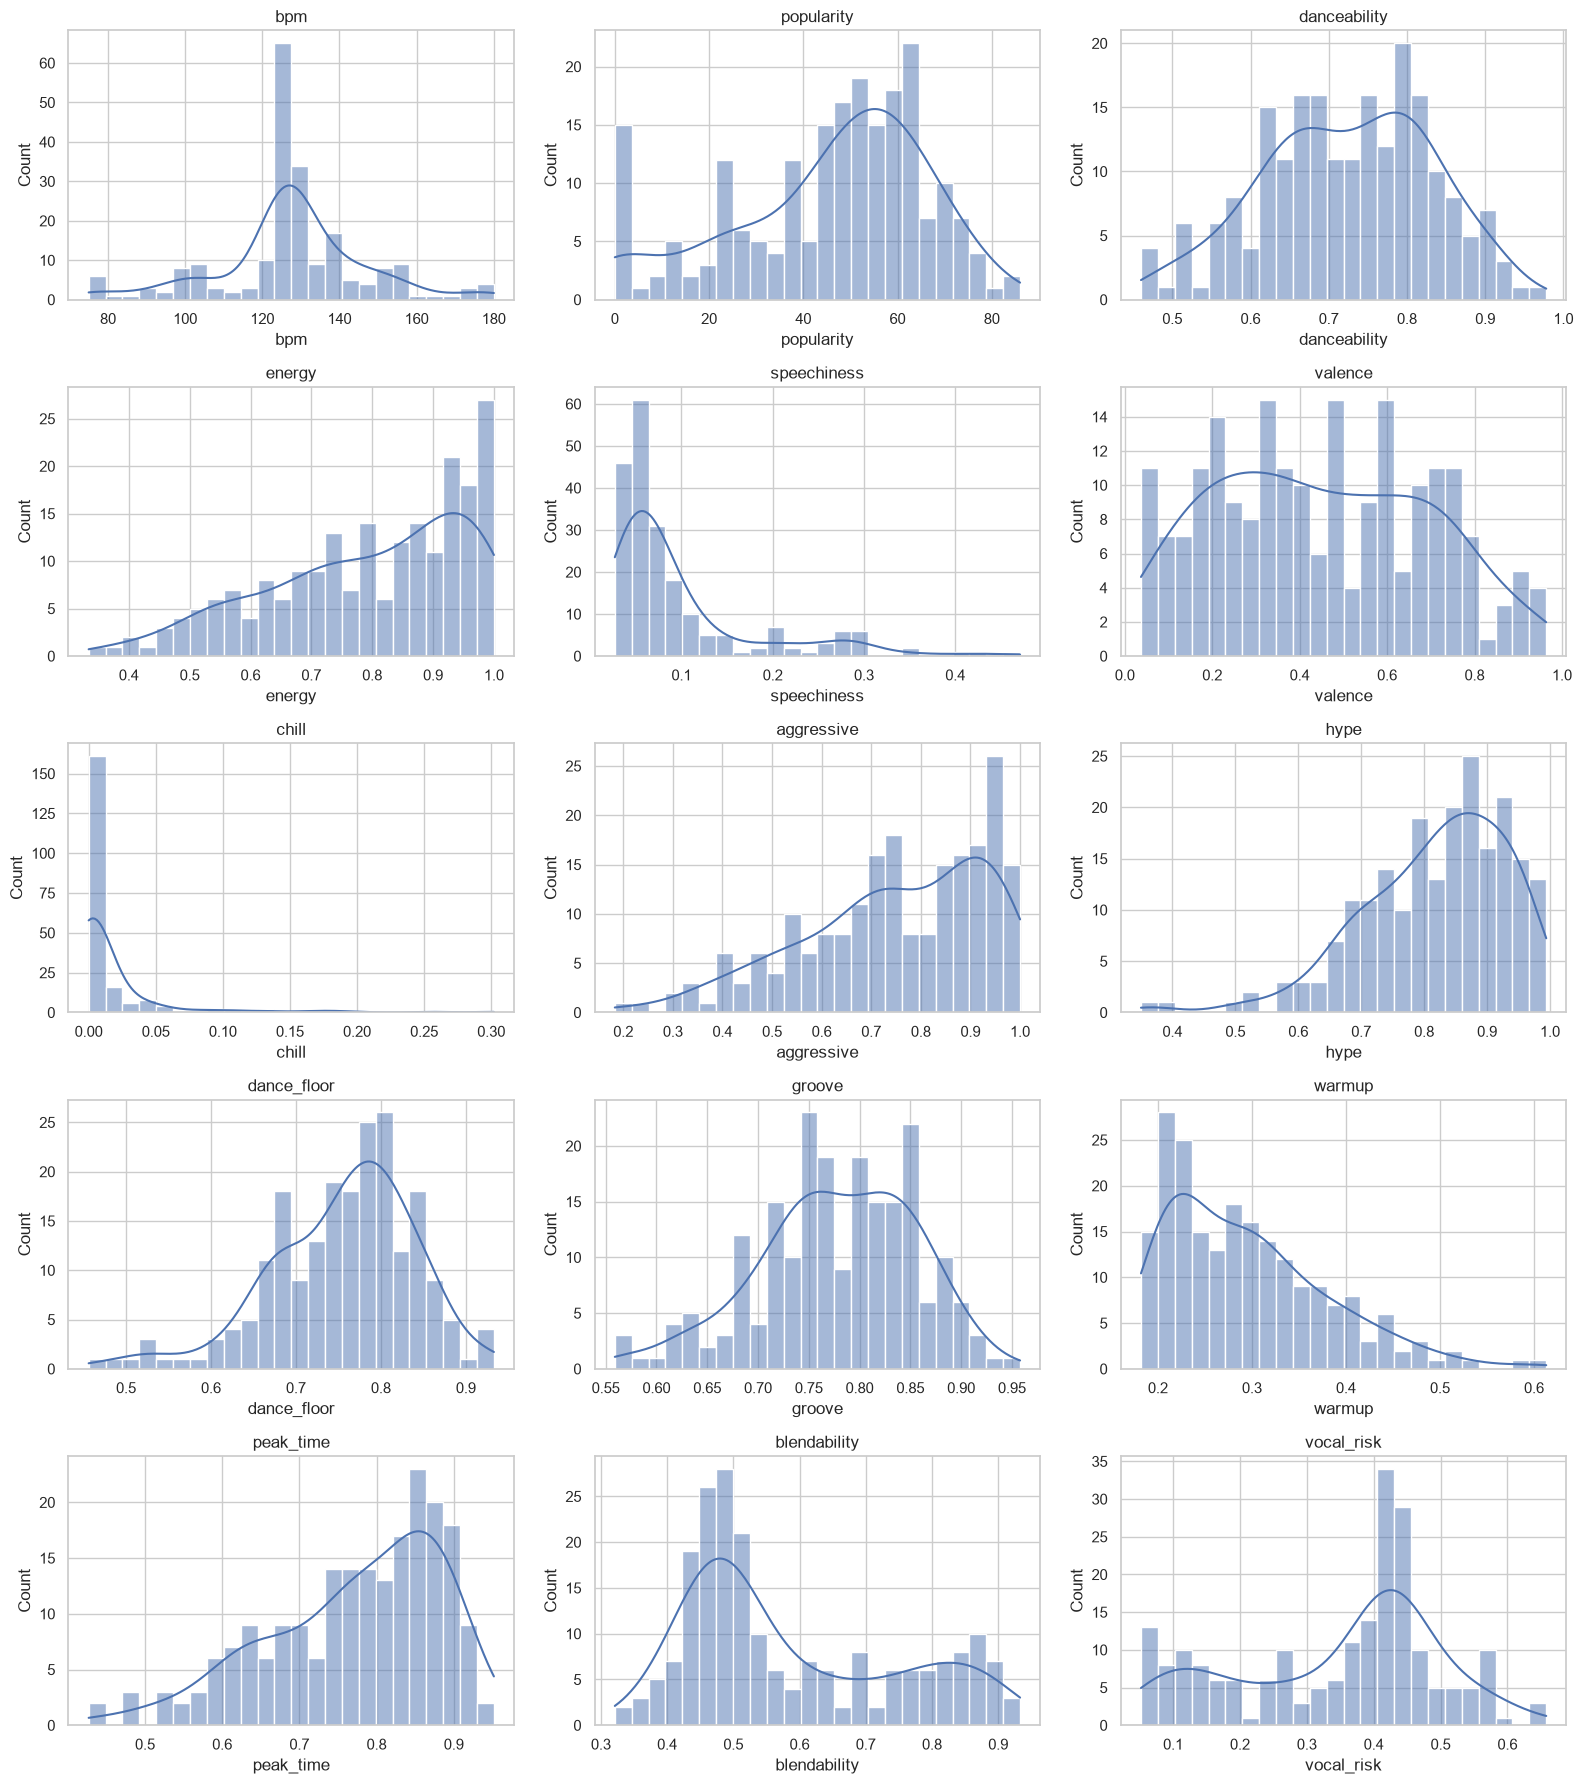

In [6]:
display(cluster_input[FEATURE_COLUMNS].describe().T)

fig, axes = plt.subplots(5, 3, figsize=(16, 18))
for ax, column in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.histplot(cluster_input[column], bins=24, kde=True, ax=ax)
    ax.set_title(column)
for ax in axes.flatten()[len(FEATURE_COLUMNS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

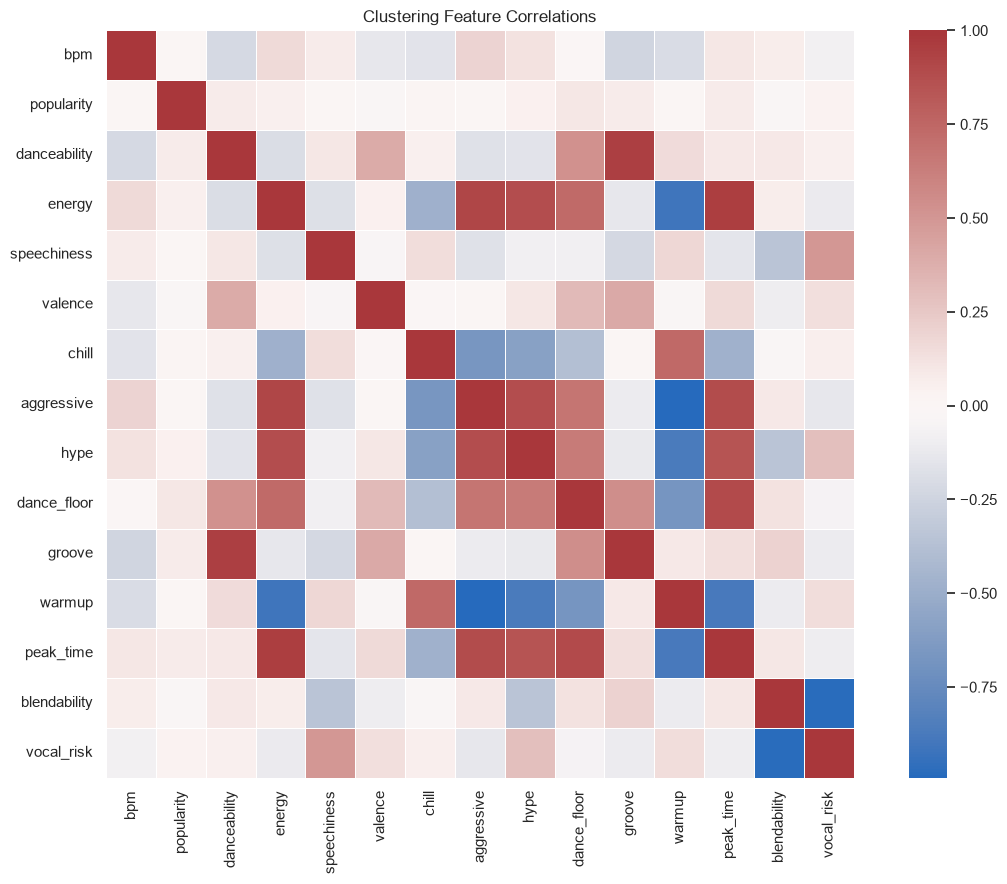

In [7]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    cluster_input[FEATURE_COLUMNS].corr(),
    cmap="vlag",
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title("Clustering Feature Correlations")
plt.tight_layout()
plt.show()

## Scale Features And Run HDBSCAN

HDBSCAN discovers dense regions without requiring a pre-selected number of clusters. The defaults below are tuned for this first exploratory pass on the current matched library: small style pockets are allowed, while noise points remain available as discovery edge cases.

Tune `MIN_CLUSTER_SIZE`, `MIN_SAMPLES`, and `CLUSTER_SELECTION_METHOD` after reviewing the first pass.

In [8]:
X_raw = cluster_input[FEATURE_COLUMNS].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

MIN_CLUSTER_SIZE = 5
MIN_SAMPLES = 1
CLUSTER_SELECTION_METHOD = "leaf"

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    prediction_data=True,
)

labels = clusterer.fit_predict(X_scaled)
cluster_input["cluster"] = labels
cluster_input["cluster_label"] = np.where(labels == -1, "noise", "cluster_" + labels.astype(str))
cluster_input["cluster_probability"] = clusterer.probabilities_
cluster_input["outlier_score"] = clusterer.outlier_scores_

cluster_count = cluster_input.loc[cluster_input["cluster"] != -1, "cluster"].nunique()
noise_count = int((cluster_input["cluster"] == -1).sum())
noise_rate = noise_count / len(cluster_input)

print(f"min_cluster_size: {MIN_CLUSTER_SIZE}")
print(f"min_samples: {MIN_SAMPLES}")
print(f"cluster_selection_method: {CLUSTER_SELECTION_METHOD}")
print(f"clusters found: {cluster_count}")
print(f"noise tracks: {noise_count:,} ({noise_rate:.1%})")

display(
    cluster_input["cluster_label"]
    .value_counts()
    .rename_axis("cluster_label")
    .reset_index(name="tracks")
)

min_cluster_size: 5
min_samples: 1
cluster_selection_method: leaf
clusters found: 9
noise tracks: 128 (61.2%)


,cluster_label,tracks
0,noise,128
1,cluster_5,23
2,cluster_2,13
3,cluster_7,11
4,cluster_6,7
5,cluster_8,7
6,cluster_0,5
7,cluster_4,5
8,cluster_1,5
9,cluster_3,5


## Visualize Cluster Separation

PCA is only used for a two-dimensional view of the standardized feature space. HDBSCAN itself uses the full feature set above.

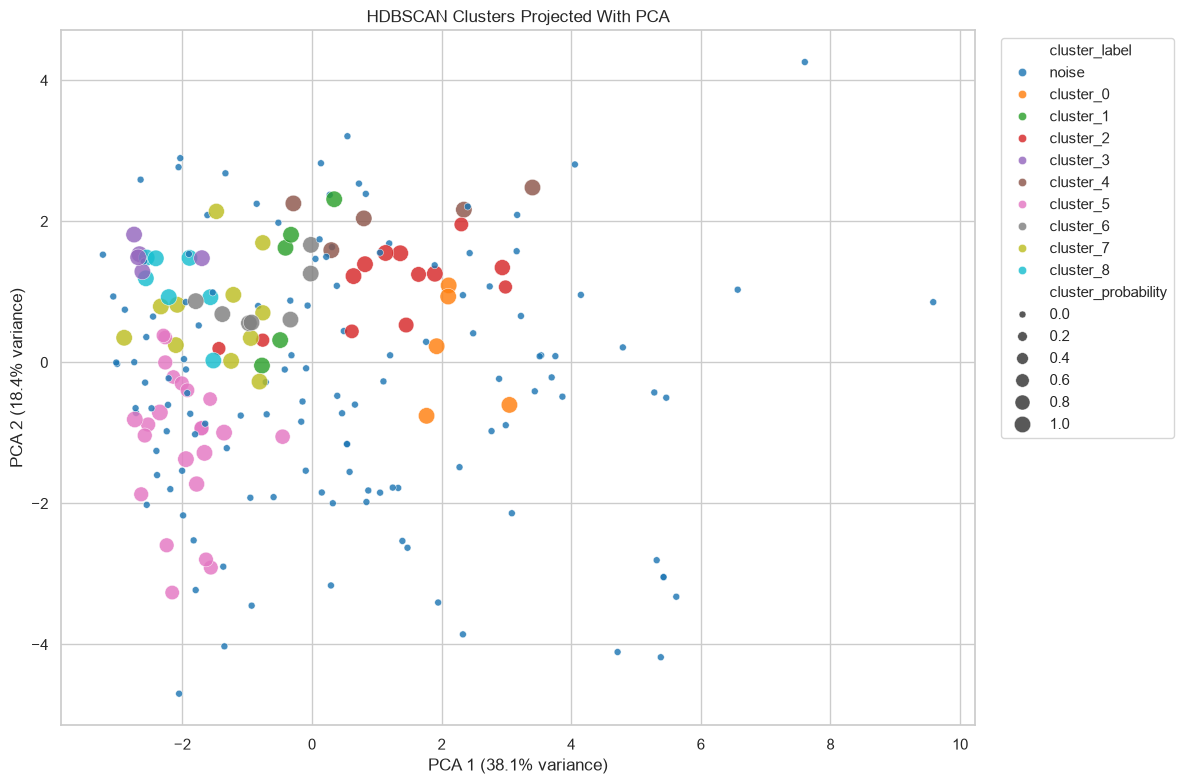

In [9]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
cluster_input["pca_1"] = pca_components[:, 0]
cluster_input["pca_2"] = pca_components[:, 1]

plot_data = cluster_input.copy()
plot_data["cluster_label"] = pd.Categorical(
    plot_data["cluster_label"],
    categories=["noise"] + sorted(
        [label for label in plot_data["cluster_label"].unique() if label != "noise"],
        key=lambda value: int(value.split("_")[1]),
    ),
    ordered=True,
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_data,
    x="pca_1",
    y="pca_2",
    hue="cluster_label",
    size="cluster_probability",
    sizes=(25, 140),
    alpha=0.82,
    palette="tab10",
)
plt.title("HDBSCAN Clusters Projected With PCA")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Cluster Profiles

The profile table compares each non-noise cluster against the library-wide complete-feature baseline. The signature table highlights the largest standardized differences that may explain what each cluster represents stylistically.

In [10]:
clustered = cluster_input[cluster_input["cluster"] != -1].copy()
global_means = cluster_input[FEATURE_COLUMNS].mean()
global_stds = cluster_input[FEATURE_COLUMNS].std(ddof=0).replace(0, np.nan)

if clustered.empty:
    print("No non-noise clusters found. Try lowering MIN_CLUSTER_SIZE or MIN_SAMPLES.")
    cluster_profile = pd.DataFrame(
        columns=[
            "cluster",
            "tracks",
            "avg_probability",
            "avg_outlier_score",
            "avg_match_score",
            "playlists",
            "artists",
        ] + [f"avg_{column}" for column in FEATURE_COLUMNS]
    )
    cluster_signatures = pd.DataFrame(
        columns=["cluster", "tracks", "top_positive_features", "top_negative_features"]
    )
else:
    cluster_profile = (
        clustered
        .groupby("cluster")
        .agg(
            tracks=("rekordbox_track_id", "count"),
            avg_probability=("cluster_probability", "mean"),
            avg_outlier_score=("outlier_score", "mean"),
            avg_match_score=("match_score", "mean"),
            playlists=("playlist_name", "nunique"),
            artists=("rekordbox_artist", "nunique"),
            **{f"avg_{column}": (column, "mean") for column in FEATURE_COLUMNS},
        )
        .reset_index()
        .sort_values(["tracks", "avg_probability"], ascending=[False, False])
    )

    signature_rows = []
    for cluster_id, frame in clustered.groupby("cluster"):
        deltas = ((frame[FEATURE_COLUMNS].mean() - global_means) / global_stds).sort_values(
            key=np.abs,
            ascending=False,
        )
        signature_rows.append(
            {
                "cluster": cluster_id,
                "tracks": len(frame),
                "top_positive_features": ", ".join(
                    f"{feature} (+{value:.2f}sd)" for feature, value in deltas[deltas > 0].head(4).items()
                ),
                "top_negative_features": ", ".join(
                    f"{feature} ({value:.2f}sd)" for feature, value in deltas[deltas < 0].head(4).items()
                ),
            }
        )
    cluster_signatures = pd.DataFrame(signature_rows).sort_values("tracks", ascending=False)

display(cluster_profile)
display(cluster_signatures)

,cluster,tracks,avg_probability,avg_outlier_score,avg_match_score,playlists,artists,avg_bpm,avg_popularity,avg_danceability,avg_energy,avg_speechiness,avg_valence,avg_chill,avg_aggressive,avg_hype,avg_dance_floor,avg_groove,avg_warmup,avg_peak_time,avg_blendability,avg_vocal_risk
5,5,23,0.813563,0.186437,0.898530,1,14,130.343391,47.695652,0.640435,0.950435,0.064087,0.326348,0.001913,0.920174,0.924609,0.779913,0.729087,0.222130,0.857348,0.568478,0.338261
2,2,13,0.850700,0.149300,0.960108,1,8,120.707231,49.846154,0.761615,0.681154,0.057923,0.191077,0.003846,0.668923,0.683692,0.725462,0.815615,0.323385,0.705308,0.845000,0.112000
7,7,11,0.980958,0.019042,0.915127,1,10,127.733818,63.000000,0.779273,0.867455,0.063273,0.571636,0.003727,0.840909,0.906545,0.819000,0.826455,0.251273,0.840909,0.503364,0.420636
6,6,7,1.000000,0.000000,0.893957,1,6,125.729857,55.857143,0.803286,0.819286,0.046857,0.277286,0.006571,0.774571,0.858714,0.810571,0.848143,0.279429,0.814429,0.554000,0.374857
8,8,7,1.000000,0.000000,0.877914,1,7,126.127429,34.428571,0.808429,0.899571,0.076714,0.661286,0.000429,0.893857,0.927714,0.849286,0.843000,0.230143,0.872286,0.516571,0.417857
0,0,5,1.000000,0.000000,0.897640,1,5,131.353800,67.400000,0.763200,0.613800,0.059600,0.251800,0.025400,0.564000,0.741600,0.696000,0.816200,0.380600,0.658600,0.505000,0.415000
1,1,5,1.000000,0.000000,0.951540,1,5,128.001200,9.800000,0.739200,0.800000,0.047600,0.720800,0.003800,0.778000,0.768400,0.766400,0.803200,0.279800,0.781600,0.796400,0.148600
3,3,5,1.000000,0.000000,0.982080,1,4,126.590600,49.000000,0.778400,0.953600,0.064200,0.565200,0.000400,0.934400,0.864000,0.857200,0.826000,0.209000,0.901000,0.792800,0.163000
4,4,5,1.000000,0.000000,0.853720,1,5,127.812600,67.600000,0.905800,0.642000,0.168600,0.699600,0.023200,0.613200,0.748800,0.787000,0.883400,0.355200,0.721200,0.542400,0.438600


,cluster,tracks,top_positive_features,top_negative_features
5,5,23,"energy (+0.97sd), aggressive (+0.93sd), hype (...","warmup (-0.86sd), danceability (-0.77sd), groo..."
2,2,13,"blendability (+1.61sd), groove (+0.49sd), danc...","vocal_risk (-1.54sd), hype (-1.17sd), valence ..."
7,7,11,"popularity (+0.83sd), hype (+0.77sd), dance_fl...","blendability (-0.53sd), warmup (-0.52sd), spee..."
6,6,7,"groove (+0.91sd), danceability (+0.73sd), danc...","valence (-0.70sd), speechiness (-0.60sd), chil..."
8,8,7,"dance_floor (+1.11sd), hype (+0.95sd), peak_ti...","warmup (-0.76sd), popularity (-0.54sd), blenda..."
0,0,5,"popularity (+1.04sd), warmup (+1.00sd), groove...","energy (-1.10sd), peak_time (-1.01sd), aggress..."
1,1,5,"blendability (+1.31sd), valence (+1.13sd), gro...","popularity (-1.73sd), vocal_risk (-1.29sd), sp..."
3,3,5,"blendability (+1.28sd), dance_floor (+1.20sd),...","vocal_risk (-1.20sd), warmup (-1.01sd), chill ..."
4,4,5,"danceability (+1.68sd), groove (+1.37sd), popu...","energy (-0.92sd), aggressive (-0.74sd), hype (..."


## Representative Tracks

High-probability tracks are good cluster exemplars. Low-probability or high-outlier-score tracks are useful for reviewing boundaries, blends, and possible expansion targets.

In [11]:
representative_columns = [
    "cluster",
    "cluster_probability",
    "outlier_score",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "bpm",
    "popularity",
    "danceability",
    "energy",
    "valence",
    "dance_floor",
    "groove",
    "warmup",
    "peak_time",
    "blendability",
    "vocal_risk",
    "spotify_url",
]

representative_tracks = (
    clustered
    .sort_values(["cluster", "cluster_probability", "outlier_score"], ascending=[True, False, True])
    .groupby("cluster", group_keys=False)
    .head(10)
    [representative_columns]
)
display(representative_tracks)

boundary_tracks = (
    clustered
    .sort_values(["cluster", "cluster_probability", "outlier_score"], ascending=[True, True, False])
    .groupby("cluster", group_keys=False)
    .head(5)
    [representative_columns]
)
display(boundary_tracks)

,cluster,cluster_probability,outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,danceability,energy,valence,dance_floor,groove,warmup,peak_time,blendability,vocal_risk,spotify_url
4,0,1.000000,0.000000,tears,"skrillex, joker, & sleepnet",Tears,"Skrillex, Joker, Sleepnet",Z,140.216,51,0.697,0.633,0.369,0.668,0.758,0.348,0.652,0.544,0.380,https://open.spotify.com/track/29tRu5BqKiUDAoW...
8,0,1.000000,0.000000,no hands (feat. roscoe dash and wale) [amended...,waka flocka flame,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",Z,131.497,78,0.760,0.595,0.361,0.686,0.820,0.363,0.644,0.488,0.423,https://open.spotify.com/track/03tqyYWC9Um2ZqU...
74,0,1.000000,0.000000,fukumean (io house edit),gunna,fukumean,Gunna,Z,130.001,82,0.847,0.622,0.220,0.746,0.866,0.389,0.690,0.488,0.454,https://open.spotify.com/track/4rXLjWdF2ZZpXCV...
147,0,1.000000,0.000000,move all night (extended mix),"kole, autograf, snbrn",Move All Night (feat. Kole),"SNBRN, Autograf, KOLE",Z,124.009,52,0.798,0.692,0.186,0.750,0.847,0.404,0.724,0.523,0.399,https://open.spotify.com/track/6kNx6oySNfaqH3P...
207,0,1.000000,0.000000,antidote,travis scott,Antidote,Travis Scott,Z,131.046,74,0.714,0.527,0.123,0.630,0.790,0.399,0.583,0.482,0.419,https://open.spotify.com/track/1wHZx0LgzFHyeIZ...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.685,0.859,0.708,0.763,0.768,0.282,0.807,0.691,0.230,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.757,0.792,0.708,0.773,0.817,0.275,0.781,0.875,0.081,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.797,0.777,0.763,0.788,0.840,0.288,0.783,0.779,0.178,https://open.spotify.com/track/5vu69csqeUJheoQ...
152,1,1.000000,0.000000,gimme some keys (original mix),matroda,Gimme Some Keys,Matroda,Z,124.992,12,0.802,0.725,0.864,0.767,0.846,0.307,0.748,0.861,0.104,https://open.spotify.com/track/5qiMjMnVdbwfifs...
185,1,1.000000,0.000000,lose my breath (kevin mckay extended remix),moreno pezzolato,Lose My Breath - Kevin McKay Extended Remix,"Moreno Pezzolato, Kevin McKay",Z,123.998,10,0.655,0.847,0.561,0.741,0.745,0.247,0.789,0.776,0.150,https://open.spotify.com/track/2WRTX5EAG8LX2AL...


,cluster,cluster_probability,outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,danceability,energy,valence,dance_floor,groove,warmup,peak_time,blendability,vocal_risk,spotify_url
4,0,1.000000,0.000000,tears,"skrillex, joker, & sleepnet",Tears,"Skrillex, Joker, Sleepnet",Z,140.216,51,0.697,0.633,0.369,0.668,0.758,0.348,0.652,0.544,0.380,https://open.spotify.com/track/29tRu5BqKiUDAoW...
8,0,1.000000,0.000000,no hands (feat. roscoe dash and wale) [amended...,waka flocka flame,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",Z,131.497,78,0.760,0.595,0.361,0.686,0.820,0.363,0.644,0.488,0.423,https://open.spotify.com/track/03tqyYWC9Um2ZqU...
74,0,1.000000,0.000000,fukumean (io house edit),gunna,fukumean,Gunna,Z,130.001,82,0.847,0.622,0.220,0.746,0.866,0.389,0.690,0.488,0.454,https://open.spotify.com/track/4rXLjWdF2ZZpXCV...
147,0,1.000000,0.000000,move all night (extended mix),"kole, autograf, snbrn",Move All Night (feat. Kole),"SNBRN, Autograf, KOLE",Z,124.009,52,0.798,0.692,0.186,0.750,0.847,0.404,0.724,0.523,0.399,https://open.spotify.com/track/6kNx6oySNfaqH3P...
207,0,1.000000,0.000000,antidote,travis scott,Antidote,Travis Scott,Z,131.046,74,0.714,0.527,0.123,0.630,0.790,0.399,0.583,0.482,0.419,https://open.spotify.com/track/1wHZx0LgzFHyeIZ...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.685,0.859,0.708,0.763,0.768,0.282,0.807,0.691,0.230,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.757,0.792,0.708,0.773,0.817,0.275,0.781,0.875,0.081,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.797,0.777,0.763,0.788,0.840,0.288,0.783,0.779,0.178,https://open.spotify.com/track/5vu69csqeUJheoQ...
152,1,1.000000,0.000000,gimme some keys (original mix),matroda,Gimme Some Keys,Matroda,Z,124.992,12,0.802,0.725,0.864,0.767,0.846,0.307,0.748,0.861,0.104,https://open.spotify.com/track/5qiMjMnVdbwfifs...
185,1,1.000000,0.000000,lose my breath (kevin mckay extended remix),moreno pezzolato,Lose My Breath - Kevin McKay Extended Remix,"Moreno Pezzolato, Kevin McKay",Z,123.998,10,0.655,0.847,0.561,0.741,0.745,0.247,0.789,0.776,0.150,https://open.spotify.com/track/2WRTX5EAG8LX2AL...


## Noise And Expansion Candidates

HDBSCAN labels `-1` as noise. These tracks may be genuine one-offs, sparse styles in the current library, incomplete style neighborhoods, or candidates for cluster expansion once more music is added.

In [12]:
noise_tracks = (
    cluster_input[cluster_input["cluster"] == -1]
    .sort_values("outlier_score", ascending=False)
    [representative_columns]
)
print(f"Noise tracks: {len(noise_tracks):,}")
display(noise_tracks.head(30))

Noise tracks: 128


,cluster,cluster_probability,outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,danceability,energy,valence,dance_floor,groove,warmup,peak_time,blendability,vocal_risk,spotify_url
23,-1,0.0,0.846765,calypso (original mix),"nxsty, ero808",Calypso,Natsu,Z,90.018,23,0.645,0.334,0.183,0.505,0.742,0.613,0.427,0.880,0.053,https://open.spotify.com/track/37u3HPOkVWbSMAG...
151,-1,0.0,0.846765,el baile,heynegaard & lvga,El Baile,"HP. Hoeger, M. Lackmaier",Z,127.015,27,0.909,0.372,0.643,0.667,0.923,0.583,0.533,0.933,0.056,https://open.spotify.com/track/54x5G6IhYHNfUT8...
139,-1,0.0,0.779579,infraliminal (original mix),"deadmau5, rezz, rezzmau5",Infraliminal,"REZZMAU5, deadmau5, Rezz",Z,180.034,24,0.586,0.447,0.037,0.523,0.623,0.445,0.489,0.748,0.234,https://open.spotify.com/track/0Z38r2LjrMNGDKI...
175,-1,0.0,0.779579,infraliminal (isabelle's version),"deadmau5, rezz, rezzmau5",Infraliminal,"REZZMAU5, deadmau5, Rezz",Z,180.034,24,0.586,0.447,0.037,0.523,0.623,0.445,0.489,0.748,0.234,https://open.spotify.com/track/0Z38r2LjrMNGDKI...
188,-1,0.0,0.775967,push it (eastmix),dave east,Push It - EASTMIX,Dave East,Z,127.950,26,0.830,0.580,0.310,0.718,0.752,0.513,0.655,0.366,0.658,https://open.spotify.com/track/4eswve9pQufeesx...
172,-1,0.0,0.772718,black ice (original mix),"rezz, subtronics",Black Ice,"Subtronics, Rezz",Z,146.955,49,0.509,0.392,0.191,0.456,0.632,0.461,0.427,0.511,0.371,https://open.spotify.com/track/1oacAKa5ReNOfuq...
145,-1,0.0,0.759380,switch,"coco palmer, deadfreshfruit",SWITCH,Eatin' & Zachor,Z,75.516,0,0.470,0.499,0.154,0.483,0.559,0.431,0.490,0.363,0.539,https://open.spotify.com/track/6EjXU1XgECsr6LG...
142,-1,0.0,0.752633,midnight,manila grey,Midnight,MANILA GREY,Z,108.949,30,0.522,0.566,0.136,0.542,0.636,0.477,0.553,0.420,0.459,https://open.spotify.com/track/7w25QXPs5bjtmym...
56,-1,0.0,0.740472,mercy,"kanye west ft. big sean, pusha t & two chainz",Mercy,"Kanye West, Big Sean, Pusha T, 2 Chainz",Z,139.993,70,0.563,0.496,0.426,0.533,0.572,0.420,0.516,0.321,0.644,https://open.spotify.com/track/4qikXelSRKvoCqF...
7,-1,0.0,0.739847,lite spots (original mix),kaytranada,LITE SPOTS,KAYTRANADA,Z,120.461,52,0.884,0.549,0.394,0.733,0.778,0.376,0.649,0.393,0.655,https://open.spotify.com/track/3Fc7k96EGOGiJBM...


## Export Cluster Assignments

Exports are written under `data/exports/`, which is ignored by git in this repo. These files can feed the next style-profile, recommendation, or discovery notebook without recomputing clusters.

In [13]:
assignment_columns = [
    "rekordbox_track_id",
    "spotify_track_id",
    "cluster",
    "cluster_label",
    "cluster_probability",
    "outlier_score",
    "pca_1",
    "pca_2",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "match_score",
    "spotify_url",
] + FEATURE_COLUMNS

assignments_path = EXPORT_DIR / "hdbscan_track_clusters.csv"
profile_path = EXPORT_DIR / "hdbscan_cluster_profiles.csv"
signatures_path = EXPORT_DIR / "hdbscan_cluster_signatures.csv"

cluster_input[assignment_columns].to_csv(assignments_path, index=False)
cluster_profile.to_csv(profile_path, index=False)
cluster_signatures.to_csv(signatures_path, index=False)

print(f"Wrote {assignments_path}")
print(f"Wrote {profile_path}")
print(f"Wrote {signatures_path}")

Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_track_clusters.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_cluster_profiles.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_cluster_signatures.csv


## Full-Feature EOM Experiment

The full-feature baseline above uses `cluster_selection_method="leaf"`, which tends to produce smaller, more granular clusters. This experiment keeps the same standardized 15-feature matrix and HDBSCAN parameters, but switches only `cluster_selection_method` to `"eom"`.

`eom` can favor more stable, broader density regions. Keeping this as a separate experiment makes it easier to decide whether the full feature space is better represented as fine-grained pockets or larger style neighborhoods.

In [14]:
FULL_EOM_MIN_CLUSTER_SIZE = MIN_CLUSTER_SIZE
FULL_EOM_MIN_SAMPLES = MIN_SAMPLES
FULL_EOM_CLUSTER_SELECTION_METHOD = "eom"

full_eom_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=FULL_EOM_MIN_CLUSTER_SIZE,
    min_samples=FULL_EOM_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=FULL_EOM_CLUSTER_SELECTION_METHOD,
    prediction_data=True,
)

full_eom_input = cluster_input.copy()
full_eom_labels = full_eom_clusterer.fit_predict(X_scaled)
full_eom_input["full_eom_cluster"] = full_eom_labels
full_eom_input["full_eom_cluster_label"] = np.where(
    full_eom_labels == -1,
    "noise",
    "full_eom_cluster_" + full_eom_labels.astype(str),
)
full_eom_input["full_eom_cluster_probability"] = full_eom_clusterer.probabilities_
full_eom_input["full_eom_outlier_score"] = full_eom_clusterer.outlier_scores_

full_eom_cluster_count = full_eom_input.loc[
    full_eom_input["full_eom_cluster"] != -1,
    "full_eom_cluster",
].nunique()
full_eom_noise_count = int((full_eom_input["full_eom_cluster"] == -1).sum())
full_eom_noise_rate = full_eom_noise_count / len(full_eom_input)

print(f"full-feature eom min_cluster_size: {FULL_EOM_MIN_CLUSTER_SIZE}")
print(f"full-feature eom min_samples: {FULL_EOM_MIN_SAMPLES}")
print(f"full-feature eom cluster_selection_method: {FULL_EOM_CLUSTER_SELECTION_METHOD}")
print(f"full-feature eom clusters found: {full_eom_cluster_count}")
print(f"full-feature eom noise tracks: {full_eom_noise_count:,} ({full_eom_noise_rate:.1%})")

display(
    full_eom_input["full_eom_cluster_label"]
    .value_counts()
    .rename_axis("full_eom_cluster_label")
    .reset_index(name="tracks")
)

full-feature eom min_cluster_size: 5
full-feature eom min_samples: 1
full-feature eom cluster_selection_method: eom
full-feature eom clusters found: 6
full-feature eom noise tracks: 98 (46.9%)


,full_eom_cluster_label,tracks
0,noise,98
1,full_eom_cluster_5,78
2,full_eom_cluster_2,13
3,full_eom_cluster_0,5
4,full_eom_cluster_4,5
5,full_eom_cluster_1,5
6,full_eom_cluster_3,5


## Visualize Full-Feature EOM Separation

This PCA view uses the same standardized full-feature matrix as the leaf run. Only the cluster labels come from the `eom` experiment.

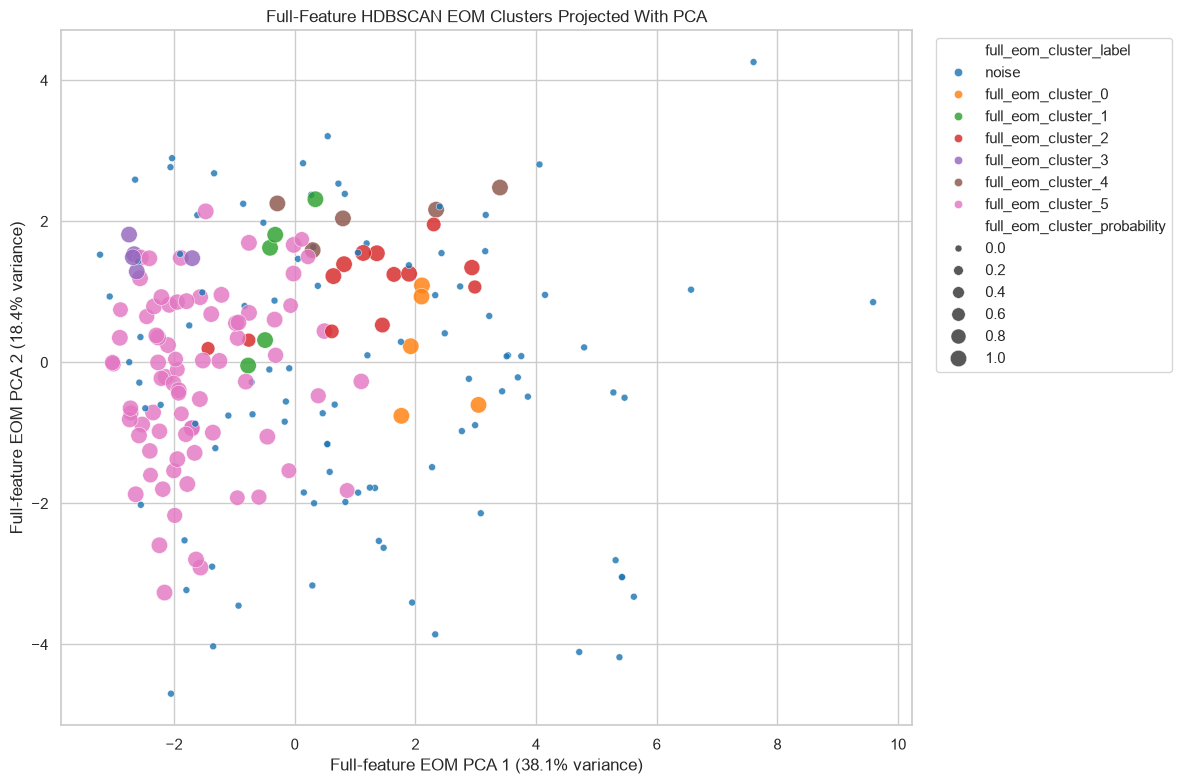

In [15]:
full_eom_pca = PCA(n_components=2, random_state=42)
full_eom_pca_components = full_eom_pca.fit_transform(X_scaled)
full_eom_input["full_eom_pca_1"] = full_eom_pca_components[:, 0]
full_eom_input["full_eom_pca_2"] = full_eom_pca_components[:, 1]

full_eom_plot_data = full_eom_input.copy()
full_eom_plot_data["full_eom_cluster_label"] = pd.Categorical(
    full_eom_plot_data["full_eom_cluster_label"],
    categories=["noise"] + sorted(
        [label for label in full_eom_plot_data["full_eom_cluster_label"].unique() if label != "noise"],
        key=lambda value: int(value.split("_")[-1]),
    ),
    ordered=True,
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=full_eom_plot_data,
    x="full_eom_pca_1",
    y="full_eom_pca_2",
    hue="full_eom_cluster_label",
    size="full_eom_cluster_probability",
    sizes=(25, 140),
    alpha=0.82,
    palette="tab10",
)
plt.title("Full-Feature HDBSCAN EOM Clusters Projected With PCA")
plt.xlabel(f"Full-feature EOM PCA 1 ({full_eom_pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Full-feature EOM PCA 2 ({full_eom_pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Full-Feature EOM Cluster Profiles

These tables mirror the full-feature leaf profiles, but summarize clusters selected with `eom`. Compare the signatures to see whether `eom` creates broader, more musically stable neighborhoods.

In [16]:
full_eom_clustered = full_eom_input[full_eom_input["full_eom_cluster"] != -1].copy()
full_eom_global_means = full_eom_input[FEATURE_COLUMNS].mean()
full_eom_global_stds = full_eom_input[FEATURE_COLUMNS].std(ddof=0).replace(0, np.nan)

if full_eom_clustered.empty:
    print("No non-noise full-feature eom clusters found. Try lowering FULL_EOM_MIN_CLUSTER_SIZE or FULL_EOM_MIN_SAMPLES.")
    full_eom_cluster_profile = pd.DataFrame(
        columns=[
            "full_eom_cluster",
            "tracks",
            "avg_probability",
            "avg_outlier_score",
            "avg_match_score",
            "playlists",
            "artists",
        ] + [f"avg_{column}" for column in FEATURE_COLUMNS]
    )
    full_eom_cluster_signatures = pd.DataFrame(
        columns=["full_eom_cluster", "tracks", "top_positive_features", "top_negative_features"]
    )
else:
    full_eom_cluster_profile = (
        full_eom_clustered
        .groupby("full_eom_cluster")
        .agg(
            tracks=("rekordbox_track_id", "count"),
            avg_probability=("full_eom_cluster_probability", "mean"),
            avg_outlier_score=("full_eom_outlier_score", "mean"),
            avg_match_score=("match_score", "mean"),
            playlists=("playlist_name", "nunique"),
            artists=("rekordbox_artist", "nunique"),
            **{f"avg_{column}": (column, "mean") for column in FEATURE_COLUMNS},
        )
        .reset_index()
        .sort_values(["tracks", "avg_probability"], ascending=[False, False])
    )

    full_eom_signature_rows = []
    for full_eom_cluster_id, frame in full_eom_clustered.groupby("full_eom_cluster"):
        full_eom_deltas = ((frame[FEATURE_COLUMNS].mean() - full_eom_global_means) / full_eom_global_stds).sort_values(
            key=np.abs,
            ascending=False,
        )
        full_eom_signature_rows.append(
            {
                "full_eom_cluster": full_eom_cluster_id,
                "tracks": len(frame),
                "top_positive_features": ", ".join(
                    f"{feature} (+{value:.2f}sd)" for feature, value in full_eom_deltas[full_eom_deltas > 0].head(4).items()
                ),
                "top_negative_features": ", ".join(
                    f"{feature} ({value:.2f}sd)" for feature, value in full_eom_deltas[full_eom_deltas < 0].head(4).items()
                ),
            }
        )
    full_eom_cluster_signatures = pd.DataFrame(full_eom_signature_rows).sort_values("tracks", ascending=False)

display(full_eom_cluster_profile)
display(full_eom_cluster_signatures)

,full_eom_cluster,tracks,avg_probability,avg_outlier_score,avg_match_score,playlists,artists,avg_bpm,avg_popularity,avg_danceability,avg_energy,avg_speechiness,avg_valence,avg_chill,avg_aggressive,avg_hype,avg_dance_floor,avg_groove,avg_warmup,avg_peak_time,avg_blendability,avg_vocal_risk
5,5,78,0.963636,0.216547,0.903414,1,59,131.783538,49.923077,0.708564,0.902500,0.066321,0.406397,0.004167,0.869949,0.900821,0.795821,0.776077,0.241205,0.844244,0.563064,0.355795
2,2,13,0.850700,0.149300,0.960108,1,8,120.707231,49.846154,0.761615,0.681154,0.057923,0.191077,0.003846,0.668923,0.683692,0.725462,0.815615,0.323385,0.705308,0.845000,0.112000
0,0,5,1.000000,0.000000,0.897640,1,5,131.353800,67.400000,0.763200,0.613800,0.059600,0.251800,0.025400,0.564000,0.741600,0.696000,0.816200,0.380600,0.658600,0.505000,0.415000
1,1,5,1.000000,0.000000,0.951540,1,5,128.001200,9.800000,0.739200,0.800000,0.047600,0.720800,0.003800,0.778000,0.768400,0.766400,0.803200,0.279800,0.781600,0.796400,0.148600
3,3,5,1.000000,0.000000,0.982080,1,4,126.590600,49.000000,0.778400,0.953600,0.064200,0.565200,0.000400,0.934400,0.864000,0.857200,0.826000,0.209000,0.901000,0.792800,0.163000
4,4,5,1.000000,0.000000,0.853720,1,5,127.812600,67.600000,0.905800,0.642000,0.168600,0.699600,0.023200,0.613200,0.748800,0.787000,0.883400,0.355200,0.721200,0.542400,0.438600


,full_eom_cluster,tracks,top_positive_features,top_negative_features
5,5,78,"hype (+0.72sd), energy (+0.67sd), aggressive (...","warmup (-0.63sd), speechiness (-0.37sd), chill..."
2,2,13,"blendability (+1.61sd), groove (+0.49sd), danc...","vocal_risk (-1.54sd), hype (-1.17sd), valence ..."
0,0,5,"popularity (+1.04sd), warmup (+1.00sd), groove...","energy (-1.10sd), peak_time (-1.01sd), aggress..."
1,1,5,"blendability (+1.31sd), valence (+1.13sd), gro...","popularity (-1.73sd), vocal_risk (-1.29sd), sp..."
3,3,5,"blendability (+1.28sd), dance_floor (+1.20sd),...","vocal_risk (-1.20sd), warmup (-1.01sd), chill ..."
4,4,5,"danceability (+1.68sd), groove (+1.37sd), popu...","energy (-0.92sd), aggressive (-0.74sd), hype (..."


## Full-Feature EOM Representative Tracks

Use these tables to review whether the broader `eom` clusters are musically coherent. Boundary and noise tracks remain useful for expansion and recommendation edge cases.

In [17]:
full_eom_representative_columns = [
    "full_eom_cluster",
    "full_eom_cluster_probability",
    "full_eom_outlier_score",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "bpm",
    "popularity",
    "danceability",
    "energy",
    "valence",
    "dance_floor",
    "groove",
    "warmup",
    "peak_time",
    "blendability",
    "vocal_risk",
    "spotify_url",
]

full_eom_representative_tracks = (
    full_eom_clustered
    .sort_values(["full_eom_cluster", "full_eom_cluster_probability", "full_eom_outlier_score"], ascending=[True, False, True])
    .groupby("full_eom_cluster", group_keys=False)
    .head(10)
    [full_eom_representative_columns]
)
display(full_eom_representative_tracks)

full_eom_boundary_tracks = (
    full_eom_clustered
    .sort_values(["full_eom_cluster", "full_eom_cluster_probability", "full_eom_outlier_score"], ascending=[True, True, False])
    .groupby("full_eom_cluster", group_keys=False)
    .head(5)
    [full_eom_representative_columns]
)
display(full_eom_boundary_tracks)

full_eom_noise_tracks = (
    full_eom_input[full_eom_input["full_eom_cluster"] == -1]
    .sort_values("full_eom_outlier_score", ascending=False)
    [full_eom_representative_columns]
)
print(f"Full-feature eom noise tracks: {len(full_eom_noise_tracks):,}")
display(full_eom_noise_tracks.head(30))

,full_eom_cluster,full_eom_cluster_probability,full_eom_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,danceability,energy,valence,dance_floor,groove,warmup,peak_time,blendability,vocal_risk,spotify_url
4,0,1.000000,0.000000,tears,"skrillex, joker, & sleepnet",Tears,"Skrillex, Joker, Sleepnet",Z,140.216,51,0.697,0.633,0.369,0.668,0.758,0.348,0.652,0.544,0.380,https://open.spotify.com/track/29tRu5BqKiUDAoW...
8,0,1.000000,0.000000,no hands (feat. roscoe dash and wale) [amended...,waka flocka flame,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",Z,131.497,78,0.760,0.595,0.361,0.686,0.820,0.363,0.644,0.488,0.423,https://open.spotify.com/track/03tqyYWC9Um2ZqU...
74,0,1.000000,0.000000,fukumean (io house edit),gunna,fukumean,Gunna,Z,130.001,82,0.847,0.622,0.220,0.746,0.866,0.389,0.690,0.488,0.454,https://open.spotify.com/track/4rXLjWdF2ZZpXCV...
147,0,1.000000,0.000000,move all night (extended mix),"kole, autograf, snbrn",Move All Night (feat. Kole),"SNBRN, Autograf, KOLE",Z,124.009,52,0.798,0.692,0.186,0.750,0.847,0.404,0.724,0.523,0.399,https://open.spotify.com/track/6kNx6oySNfaqH3P...
207,0,1.000000,0.000000,antidote,travis scott,Antidote,Travis Scott,Z,131.046,74,0.714,0.527,0.123,0.630,0.790,0.399,0.583,0.482,0.419,https://open.spotify.com/track/1wHZx0LgzFHyeIZ...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.685,0.859,0.708,0.763,0.768,0.282,0.807,0.691,0.230,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.757,0.792,0.708,0.773,0.817,0.275,0.781,0.875,0.081,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.797,0.777,0.763,0.788,0.840,0.288,0.783,0.779,0.178,https://open.spotify.com/track/5vu69csqeUJheoQ...
152,1,1.000000,0.000000,gimme some keys (original mix),matroda,Gimme Some Keys,Matroda,Z,124.992,12,0.802,0.725,0.864,0.767,0.846,0.307,0.748,0.861,0.104,https://open.spotify.com/track/5qiMjMnVdbwfifs...
185,1,1.000000,0.000000,lose my breath (kevin mckay extended remix),moreno pezzolato,Lose My Breath - Kevin McKay Extended Remix,"Moreno Pezzolato, Kevin McKay",Z,123.998,10,0.655,0.847,0.561,0.741,0.745,0.247,0.789,0.776,0.150,https://open.spotify.com/track/2WRTX5EAG8LX2AL...


,full_eom_cluster,full_eom_cluster_probability,full_eom_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,danceability,energy,valence,dance_floor,groove,warmup,peak_time,blendability,vocal_risk,spotify_url
4,0,1.000000,0.000000,tears,"skrillex, joker, & sleepnet",Tears,"Skrillex, Joker, Sleepnet",Z,140.216,51,0.697,0.633,0.369,0.668,0.758,0.348,0.652,0.544,0.380,https://open.spotify.com/track/29tRu5BqKiUDAoW...
8,0,1.000000,0.000000,no hands (feat. roscoe dash and wale) [amended...,waka flocka flame,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",Z,131.497,78,0.760,0.595,0.361,0.686,0.820,0.363,0.644,0.488,0.423,https://open.spotify.com/track/03tqyYWC9Um2ZqU...
74,0,1.000000,0.000000,fukumean (io house edit),gunna,fukumean,Gunna,Z,130.001,82,0.847,0.622,0.220,0.746,0.866,0.389,0.690,0.488,0.454,https://open.spotify.com/track/4rXLjWdF2ZZpXCV...
147,0,1.000000,0.000000,move all night (extended mix),"kole, autograf, snbrn",Move All Night (feat. Kole),"SNBRN, Autograf, KOLE",Z,124.009,52,0.798,0.692,0.186,0.750,0.847,0.404,0.724,0.523,0.399,https://open.spotify.com/track/6kNx6oySNfaqH3P...
207,0,1.000000,0.000000,antidote,travis scott,Antidote,Travis Scott,Z,131.046,74,0.714,0.527,0.123,0.630,0.790,0.399,0.583,0.482,0.419,https://open.spotify.com/track/1wHZx0LgzFHyeIZ...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.685,0.859,0.708,0.763,0.768,0.282,0.807,0.691,0.230,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.757,0.792,0.708,0.773,0.817,0.275,0.781,0.875,0.081,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.797,0.777,0.763,0.788,0.840,0.288,0.783,0.779,0.178,https://open.spotify.com/track/5vu69csqeUJheoQ...
152,1,1.000000,0.000000,gimme some keys (original mix),matroda,Gimme Some Keys,Matroda,Z,124.992,12,0.802,0.725,0.864,0.767,0.846,0.307,0.748,0.861,0.104,https://open.spotify.com/track/5qiMjMnVdbwfifs...
185,1,1.000000,0.000000,lose my breath (kevin mckay extended remix),moreno pezzolato,Lose My Breath - Kevin McKay Extended Remix,"Moreno Pezzolato, Kevin McKay",Z,123.998,10,0.655,0.847,0.561,0.741,0.745,0.247,0.789,0.776,0.150,https://open.spotify.com/track/2WRTX5EAG8LX2AL...


Full-feature eom noise tracks: 98


,full_eom_cluster,full_eom_cluster_probability,full_eom_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,danceability,energy,valence,dance_floor,groove,warmup,peak_time,blendability,vocal_risk,spotify_url
23,-1,0.0,0.846765,calypso (original mix),"nxsty, ero808",Calypso,Natsu,Z,90.018,23,0.645,0.334,0.183,0.505,0.742,0.613,0.427,0.880,0.053,https://open.spotify.com/track/37u3HPOkVWbSMAG...
151,-1,0.0,0.846765,el baile,heynegaard & lvga,El Baile,"HP. Hoeger, M. Lackmaier",Z,127.015,27,0.909,0.372,0.643,0.667,0.923,0.583,0.533,0.933,0.056,https://open.spotify.com/track/54x5G6IhYHNfUT8...
139,-1,0.0,0.779579,infraliminal (original mix),"deadmau5, rezz, rezzmau5",Infraliminal,"REZZMAU5, deadmau5, Rezz",Z,180.034,24,0.586,0.447,0.037,0.523,0.623,0.445,0.489,0.748,0.234,https://open.spotify.com/track/0Z38r2LjrMNGDKI...
175,-1,0.0,0.779579,infraliminal (isabelle's version),"deadmau5, rezz, rezzmau5",Infraliminal,"REZZMAU5, deadmau5, Rezz",Z,180.034,24,0.586,0.447,0.037,0.523,0.623,0.445,0.489,0.748,0.234,https://open.spotify.com/track/0Z38r2LjrMNGDKI...
188,-1,0.0,0.775967,push it (eastmix),dave east,Push It - EASTMIX,Dave East,Z,127.950,26,0.830,0.580,0.310,0.718,0.752,0.513,0.655,0.366,0.658,https://open.spotify.com/track/4eswve9pQufeesx...
172,-1,0.0,0.772718,black ice (original mix),"rezz, subtronics",Black Ice,"Subtronics, Rezz",Z,146.955,49,0.509,0.392,0.191,0.456,0.632,0.461,0.427,0.511,0.371,https://open.spotify.com/track/1oacAKa5ReNOfuq...
145,-1,0.0,0.759380,switch,"coco palmer, deadfreshfruit",SWITCH,Eatin' & Zachor,Z,75.516,0,0.470,0.499,0.154,0.483,0.559,0.431,0.490,0.363,0.539,https://open.spotify.com/track/6EjXU1XgECsr6LG...
142,-1,0.0,0.752633,midnight,manila grey,Midnight,MANILA GREY,Z,108.949,30,0.522,0.566,0.136,0.542,0.636,0.477,0.553,0.420,0.459,https://open.spotify.com/track/7w25QXPs5bjtmym...
56,-1,0.0,0.740472,mercy,"kanye west ft. big sean, pusha t & two chainz",Mercy,"Kanye West, Big Sean, Pusha T, 2 Chainz",Z,139.993,70,0.563,0.496,0.426,0.533,0.572,0.420,0.516,0.321,0.644,https://open.spotify.com/track/4qikXelSRKvoCqF...
7,-1,0.0,0.739847,lite spots (original mix),kaytranada,LITE SPOTS,KAYTRANADA,Z,120.461,52,0.884,0.549,0.394,0.733,0.778,0.376,0.649,0.393,0.655,https://open.spotify.com/track/3Fc7k96EGOGiJBM...


## Export Full-Feature EOM Assignments

These exports use separate filenames so the full-feature `leaf` outputs remain unchanged.

In [18]:
full_eom_assignment_columns = [
    "rekordbox_track_id",
    "spotify_track_id",
    "cluster",
    "cluster_label",
    "cluster_probability",
    "outlier_score",
    "full_eom_cluster",
    "full_eom_cluster_label",
    "full_eom_cluster_probability",
    "full_eom_outlier_score",
    "full_eom_pca_1",
    "full_eom_pca_2",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "match_score",
    "spotify_url",
] + FEATURE_COLUMNS

full_eom_assignments_path = EXPORT_DIR / "hdbscan_full_eom_track_clusters.csv"
full_eom_profile_path = EXPORT_DIR / "hdbscan_full_eom_cluster_profiles.csv"
full_eom_signatures_path = EXPORT_DIR / "hdbscan_full_eom_cluster_signatures.csv"

full_eom_input[full_eom_assignment_columns].to_csv(full_eom_assignments_path, index=False)
full_eom_cluster_profile.to_csv(full_eom_profile_path, index=False)
full_eom_cluster_signatures.to_csv(full_eom_signatures_path, index=False)

print(f"Wrote {full_eom_assignments_path}")
print(f"Wrote {full_eom_profile_path}")
print(f"Wrote {full_eom_signatures_path}")

Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_full_eom_track_clusters.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_full_eom_cluster_profiles.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_full_eom_cluster_signatures.csv


## Composite Feature Clustering Rationale

The full-feature model above keeps every analysis signal separate. That is useful for auditability, but it can overweight redundant musical dimensions when several columns describe the same idea. For example, `energy`, `hype`, `peak_time`, `dance_floor`, and `aggressive` can all push tracks along a similar intensity axis.

This second pass keeps the original work intact and adds an interpretable composite feature space. The goal is to cluster on fewer, more musical dimensions so HDBSCAN is less dominated by repeated versions of the same signal.

Composite groups used here:

- `intensity`: energy, hype, peak time, dance floor, aggressive
- `warmth`: chill, warmup, valence
- `mixability`: danceability, groove, blendability
- `vocal_presence`: speechiness, vocal risk
- `bpm` and `popularity` remain standalone because they have clear independent meaning.


In [19]:
COMPOSITE_FEATURE_DEFINITIONS = {
    "intensity": ["energy", "hype", "peak_time", "dance_floor", "aggressive"],
    "warmth": ["chill", "warmup", "valence"],
    "mixability": ["danceability", "groove", "blendability"],
    "vocal_presence": ["speechiness", "vocal_risk"],
}

COMPOSITE_FEATURE_COLUMNS = [
    "bpm",
    "popularity",
    "intensity",
    "warmth",
    "mixability",
    "vocal_presence",
]

composite_input = cluster_input.copy()
for composite_feature, source_features in COMPOSITE_FEATURE_DEFINITIONS.items():
    composite_input[composite_feature] = composite_input[source_features].mean(axis=1)

composite_feature_map = pd.DataFrame(
    [
        {
            "composite_feature": composite_feature,
            "source_features": ", ".join(source_features),
        }
        for composite_feature, source_features in COMPOSITE_FEATURE_DEFINITIONS.items()
    ]
    + [
        {"composite_feature": "bpm", "source_features": "bpm"},
        {"composite_feature": "popularity", "source_features": "popularity"},
    ]
)

display(composite_feature_map)
display(composite_input[COMPOSITE_FEATURE_COLUMNS].describe().T)


,composite_feature,source_features
0,intensity,"energy, hype, peak_time, dance_floor, aggressive"
1,warmth,"chill, warmup, valence"
2,mixability,"danceability, groove, blendability"
3,vocal_presence,"speechiness, vocal_risk"
4,bpm,bpm
5,popularity,popularity


,count,mean,std,min,25%,50%,75%,max
bpm,209.0,127.703120,19.540062,74.981000,124.002000,126.074000,137.998000,180.034000
popularity,209.0,45.751196,20.849629,0.000000,34.000000,51.000000,61.000000,86.000000
intensity,209.0,0.777464,0.124453,0.359800,0.697200,0.798200,0.881800,0.961000
warmth,209.0,0.253278,0.089581,0.088667,0.182667,0.246000,0.316333,0.494333
mixability,209.0,0.696303,0.086778,0.464000,0.640000,0.694333,0.758000,0.921667
vocal_presence,209.0,0.221361,0.103623,0.043000,0.145000,0.229000,0.260500,0.563000


## Composite Feature Distributions

The composite distributions should be easier to interpret than the full feature set: they describe tempo, reach, intensity, warmth, mixability, and vocal risk/presence as the dimensions HDBSCAN sees.


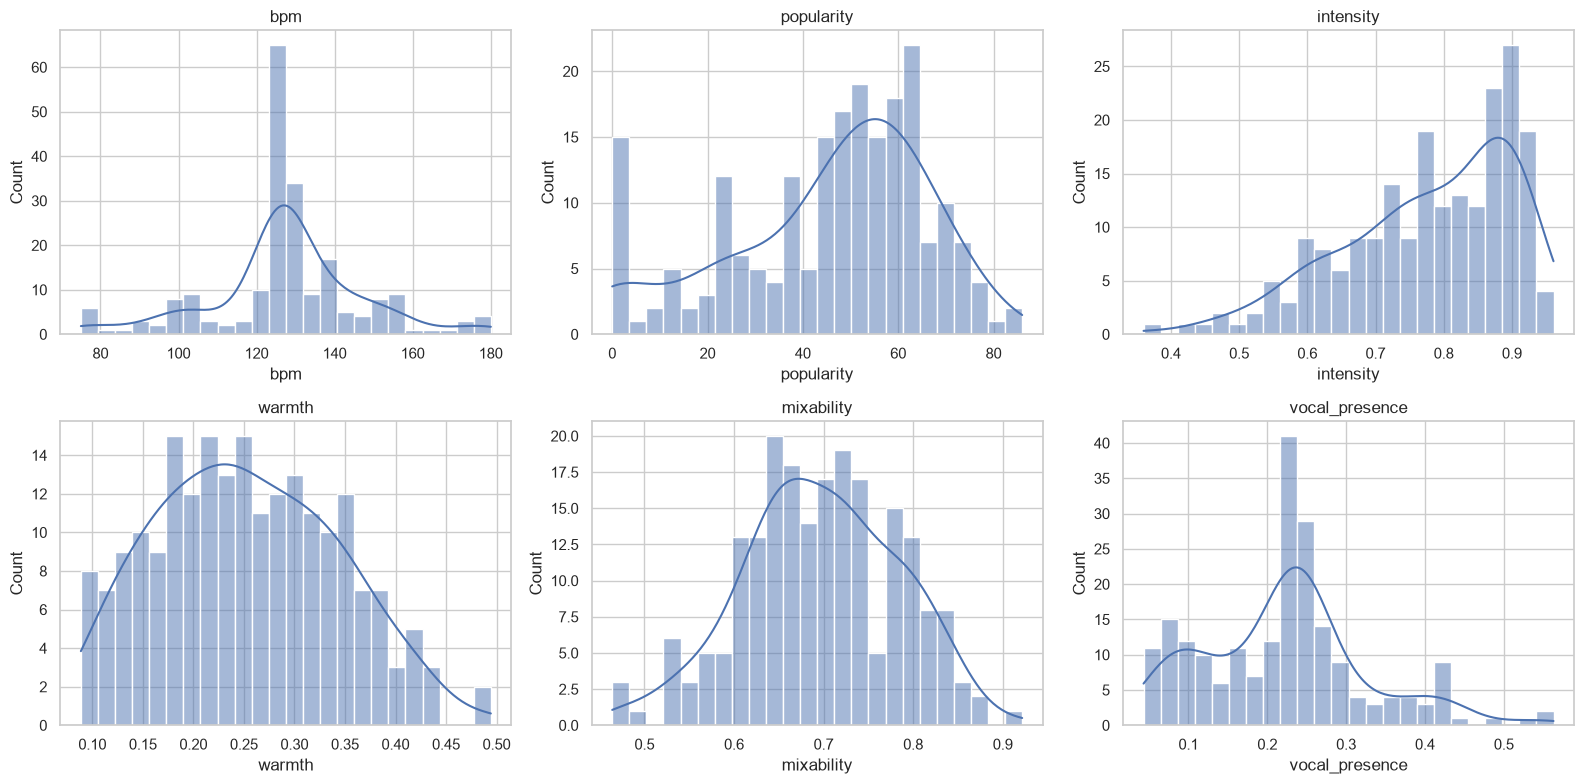

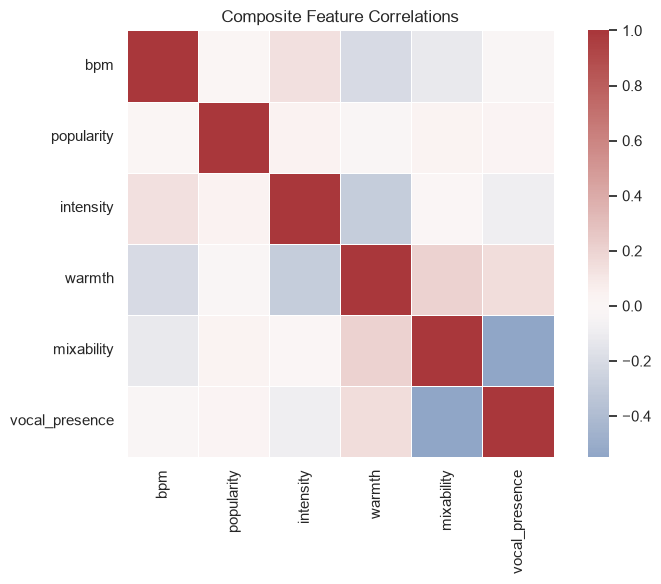

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, column in zip(axes.flatten(), COMPOSITE_FEATURE_COLUMNS):
    sns.histplot(composite_input[column], bins=24, kde=True, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    composite_input[COMPOSITE_FEATURE_COLUMNS].corr(),
    cmap="vlag",
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title("Composite Feature Correlations")
plt.tight_layout()
plt.show()


## Run HDBSCAN On Composite Features

This mirrors the full-feature HDBSCAN path, but uses the composite feature matrix. The defaults match the exploratory baseline above so differences are driven primarily by the feature representation.


In [21]:
X_composite_raw = composite_input[COMPOSITE_FEATURE_COLUMNS].copy()
composite_scaler = StandardScaler()
X_composite_scaled = composite_scaler.fit_transform(X_composite_raw)

COMPOSITE_MIN_CLUSTER_SIZE = 5
COMPOSITE_MIN_SAMPLES = 1
COMPOSITE_CLUSTER_SELECTION_METHOD = "leaf"

composite_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=COMPOSITE_MIN_CLUSTER_SIZE,
    min_samples=COMPOSITE_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=COMPOSITE_CLUSTER_SELECTION_METHOD,
    prediction_data=True,
)

composite_labels = composite_clusterer.fit_predict(X_composite_scaled)
composite_input["composite_cluster"] = composite_labels
composite_input["composite_cluster_label"] = np.where(
    composite_labels == -1,
    "noise",
    "composite_cluster_" + composite_labels.astype(str),
)
composite_input["composite_cluster_probability"] = composite_clusterer.probabilities_
composite_input["composite_outlier_score"] = composite_clusterer.outlier_scores_

composite_cluster_count = composite_input.loc[
    composite_input["composite_cluster"] != -1,
    "composite_cluster",
].nunique()
composite_noise_count = int((composite_input["composite_cluster"] == -1).sum())
composite_noise_rate = composite_noise_count / len(composite_input)

print(f"composite min_cluster_size: {COMPOSITE_MIN_CLUSTER_SIZE}")
print(f"composite min_samples: {COMPOSITE_MIN_SAMPLES}")
print(f"composite cluster_selection_method: {COMPOSITE_CLUSTER_SELECTION_METHOD}")
print(f"composite clusters found: {composite_cluster_count}")
print(f"composite noise tracks: {composite_noise_count:,} ({composite_noise_rate:.1%})")

display(
    composite_input["composite_cluster_label"]
    .value_counts()
    .rename_axis("composite_cluster_label")
    .reset_index(name="tracks")
)


composite min_cluster_size: 5
composite min_samples: 1
composite cluster_selection_method: leaf
composite clusters found: 10
composite noise tracks: 134 (64.1%)


,composite_cluster_label,tracks
0,noise,134
1,composite_cluster_8,13
2,composite_cluster_7,10
3,composite_cluster_3,9
4,composite_cluster_2,8
5,composite_cluster_4,7
6,composite_cluster_1,7
7,composite_cluster_9,6
8,composite_cluster_5,5
9,composite_cluster_0,5


## Visualize Composite Cluster Separation

This PCA view is generated from the standardized composite feature space. It is directly comparable to the earlier PCA view, but the axes now summarize six composite dimensions instead of all fifteen original features.


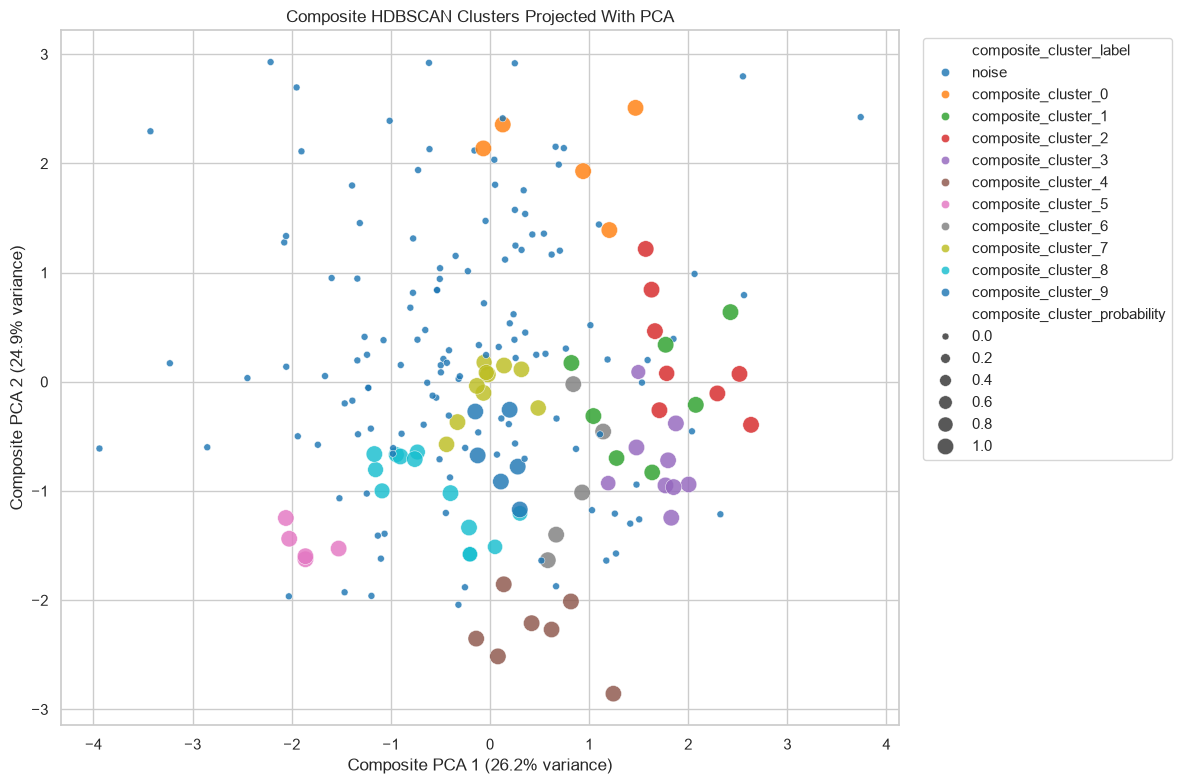

In [22]:
composite_pca = PCA(n_components=2, random_state=42)
composite_pca_components = composite_pca.fit_transform(X_composite_scaled)
composite_input["composite_pca_1"] = composite_pca_components[:, 0]
composite_input["composite_pca_2"] = composite_pca_components[:, 1]

composite_plot_data = composite_input.copy()
composite_plot_data["composite_cluster_label"] = pd.Categorical(
    composite_plot_data["composite_cluster_label"],
    categories=["noise"] + sorted(
        [label for label in composite_plot_data["composite_cluster_label"].unique() if label != "noise"],
        key=lambda value: int(value.split("_")[-1]),
    ),
    ordered=True,
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=composite_plot_data,
    x="composite_pca_1",
    y="composite_pca_2",
    hue="composite_cluster_label",
    size="composite_cluster_probability",
    sizes=(25, 140),
    alpha=0.82,
    palette="tab10",
)
plt.title("Composite HDBSCAN Clusters Projected With PCA")
plt.xlabel(f"Composite PCA 1 ({composite_pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Composite PCA 2 ({composite_pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Composite Cluster Profiles

These profile and signature tables use the composite dimensions for interpretation. The signature table highlights which composite dimensions most distinguish each cluster from the complete matched-track baseline.


In [23]:
composite_clustered = composite_input[composite_input["composite_cluster"] != -1].copy()
composite_global_means = composite_input[COMPOSITE_FEATURE_COLUMNS].mean()
composite_global_stds = composite_input[COMPOSITE_FEATURE_COLUMNS].std(ddof=0).replace(0, np.nan)

if composite_clustered.empty:
    print("No non-noise composite clusters found. Try lowering COMPOSITE_MIN_CLUSTER_SIZE or COMPOSITE_MIN_SAMPLES.")
    composite_cluster_profile = pd.DataFrame(
        columns=[
            "composite_cluster",
            "tracks",
            "avg_probability",
            "avg_outlier_score",
            "avg_match_score",
            "playlists",
            "artists",
        ] + [f"avg_{column}" for column in COMPOSITE_FEATURE_COLUMNS]
    )
    composite_cluster_signatures = pd.DataFrame(
        columns=["composite_cluster", "tracks", "top_positive_features", "top_negative_features"]
    )
else:
    composite_cluster_profile = (
        composite_clustered
        .groupby("composite_cluster")
        .agg(
            tracks=("rekordbox_track_id", "count"),
            avg_probability=("composite_cluster_probability", "mean"),
            avg_outlier_score=("composite_outlier_score", "mean"),
            avg_match_score=("match_score", "mean"),
            playlists=("playlist_name", "nunique"),
            artists=("rekordbox_artist", "nunique"),
            **{f"avg_{column}": (column, "mean") for column in COMPOSITE_FEATURE_COLUMNS},
        )
        .reset_index()
        .sort_values(["tracks", "avg_probability"], ascending=[False, False])
    )

    composite_signature_rows = []
    for composite_cluster_id, frame in composite_clustered.groupby("composite_cluster"):
        composite_deltas = ((frame[COMPOSITE_FEATURE_COLUMNS].mean() - composite_global_means) / composite_global_stds).sort_values(
            key=np.abs,
            ascending=False,
        )
        composite_signature_rows.append(
            {
                "composite_cluster": composite_cluster_id,
                "tracks": len(frame),
                "top_positive_features": ", ".join(
                    f"{feature} (+{value:.2f}sd)" for feature, value in composite_deltas[composite_deltas > 0].head(4).items()
                ),
                "top_negative_features": ", ".join(
                    f"{feature} ({value:.2f}sd)" for feature, value in composite_deltas[composite_deltas < 0].head(4).items()
                ),
            }
        )
    composite_cluster_signatures = pd.DataFrame(composite_signature_rows).sort_values("tracks", ascending=False)

display(composite_cluster_profile)
display(composite_cluster_signatures)


,composite_cluster,tracks,avg_probability,avg_outlier_score,avg_match_score,playlists,artists,avg_bpm,avg_popularity,avg_intensity,avg_warmth,avg_mixability,avg_vocal_presence
8,8,13,0.917893,0.082107,0.906485,1,8,128.460385,46.076923,0.882492,0.174692,0.652692,0.208769
7,7,10,0.973996,0.026004,0.911350,1,10,127.404400,63.300000,0.836560,0.280600,0.701967,0.237250
3,3,9,0.950347,0.049653,0.970156,1,5,125.670222,47.333333,0.680133,0.163963,0.819148,0.081667
2,2,8,0.991458,0.008542,0.905575,1,8,124.762250,52.750000,0.790400,0.360458,0.827417,0.122188
4,4,7,0.994790,0.005210,0.965171,1,7,151.586286,53.571429,0.911314,0.142905,0.758810,0.121143
1,1,7,0.991416,0.008584,0.958986,1,6,127.995571,14.142857,0.817029,0.322143,0.784238,0.103071
9,9,6,1.000000,0.000000,0.884300,1,5,126.179333,54.500000,0.823367,0.188611,0.726722,0.216167
0,0,5,1.000000,0.000000,0.960640,1,5,116.030400,58.400000,0.592920,0.395133,0.728067,0.247200
5,5,5,1.000000,0.000000,0.919860,1,4,140.987600,47.800000,0.895760,0.121467,0.564067,0.254100
6,6,5,1.000000,0.000000,0.885500,1,4,124.805600,50.400000,0.886280,0.251533,0.718200,0.103400


,composite_cluster,tracks,top_positive_features,top_negative_features
8,8,13,"intensity (+0.85sd), bpm (+0.04sd), popularity...","warmth (-0.88sd), mixability (-0.50sd), vocal_..."
7,7,10,"popularity (+0.84sd), intensity (+0.48sd), war...",bpm (-0.02sd)
3,3,9,"mixability (+1.42sd), popularity (+0.08sd)","vocal_presence (-1.35sd), warmth (-1.00sd), in..."
2,2,8,"mixability (+1.51sd), warmth (+1.20sd), popula...","vocal_presence (-0.96sd), bpm (-0.15sd)"
1,1,7,"mixability (+1.02sd), warmth (+0.77sd), intens...","popularity (-1.52sd), vocal_presence (-1.14sd)"
4,4,7,"bpm (+1.23sd), intensity (+1.08sd), mixability...","warmth (-1.24sd), vocal_presence (-0.97sd)"
9,9,6,"popularity (+0.42sd), intensity (+0.37sd), mix...","warmth (-0.72sd), bpm (-0.08sd), vocal_presenc..."
0,0,5,"warmth (+1.59sd), popularity (+0.61sd), mixabi...","intensity (-1.49sd), bpm (-0.60sd)"
5,5,5,"intensity (+0.95sd), bpm (+0.68sd), vocal_pres...","mixability (-1.53sd), warmth (-1.47sd)"
6,6,5,"intensity (+0.88sd), mixability (+0.25sd), pop...","vocal_presence (-1.14sd), bpm (-0.15sd), warmt..."


## Composite Representative Tracks

High-probability tracks are strong examples of each composite cluster. Boundary tracks are useful for understanding where the composite representation may merge or split style neighborhoods differently from the full-feature model.


In [24]:
composite_representative_columns = [
    "composite_cluster",
    "composite_cluster_probability",
    "composite_outlier_score",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "bpm",
    "popularity",
    "intensity",
    "warmth",
    "mixability",
    "vocal_presence",
    "spotify_url",
]

composite_representative_tracks = (
    composite_clustered
    .sort_values(["composite_cluster", "composite_cluster_probability", "composite_outlier_score"], ascending=[True, False, True])
    .groupby("composite_cluster", group_keys=False)
    .head(10)
    [composite_representative_columns]
)
display(composite_representative_tracks)

composite_boundary_tracks = (
    composite_clustered
    .sort_values(["composite_cluster", "composite_cluster_probability", "composite_outlier_score"], ascending=[True, True, False])
    .groupby("composite_cluster", group_keys=False)
    .head(5)
    [composite_representative_columns]
)
display(composite_boundary_tracks)


,composite_cluster,composite_cluster_probability,composite_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,intensity,warmth,mixability,vocal_presence,spotify_url
12,0,1.000000,0.000000,faking it [explicit],calvin harris feat. kehlani & lil yachty,Faking It (feat. Kehlani & Lil Yachty),"Calvin Harris, Kehlani, Lil Yachty, Funk Wav",Z,120.034,59,0.6002,0.426667,0.683333,0.2920,https://open.spotify.com/track/0pJPdSVti6cTM1Q...
121,0,1.000000,0.000000,10count,rym,10count,Rym,Z,107.020,64,0.5272,0.406000,0.784333,0.2320,https://open.spotify.com/track/06dAXZd6k4eAnco...
125,0,1.000000,0.000000,faded (original mix),zhu,Faded,ZHU,Z,124.979,59,0.5788,0.344000,0.781333,0.2040,https://open.spotify.com/track/2GQEM9JuHu30sGF...
140,0,1.000000,0.000000,i wanna be your lover (original mix),prince,I Wanna Be Your Lover,Prince,Z,114.832,58,0.5890,0.384667,0.734000,0.2190,https://open.spotify.com/track/2XLAzm8bMDSI7Mh...
174,0,1.000000,0.000000,weight on my shoulders [explicit],rod wave,Weight On My Shoulders,Rod Wave,Z,113.287,52,0.6694,0.414333,0.657333,0.2890,https://open.spotify.com/track/5PVHJQ1iuQZ7srM...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.7982,0.336000,0.714667,0.1340,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.7768,0.327667,0.816333,0.0625,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.7788,0.350333,0.805333,0.1190,https://open.spotify.com/track/5vu69csqeUJheoQ...
152,1,1.000000,0.000000,gimme some keys (original mix),matroda,Gimme Some Keys,Matroda,Z,124.992,12,0.7350,0.390667,0.836333,0.0780,https://open.spotify.com/track/5qiMjMnVdbwfifs...
185,1,1.000000,0.000000,lose my breath (kevin mckay extended remix),moreno pezzolato,Lose My Breath - Kevin McKay Extended Remix,"Moreno Pezzolato, Kevin McKay",Z,123.998,10,0.8056,0.269333,0.725333,0.0970,https://open.spotify.com/track/2WRTX5EAG8LX2AL...


,composite_cluster,composite_cluster_probability,composite_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,intensity,warmth,mixability,vocal_presence,spotify_url
12,0,1.000000,0.000000,faking it [explicit],calvin harris feat. kehlani & lil yachty,Faking It (feat. Kehlani & Lil Yachty),"Calvin Harris, Kehlani, Lil Yachty, Funk Wav",Z,120.034,59,0.6002,0.426667,0.683333,0.2920,https://open.spotify.com/track/0pJPdSVti6cTM1Q...
121,0,1.000000,0.000000,10count,rym,10count,Rym,Z,107.020,64,0.5272,0.406000,0.784333,0.2320,https://open.spotify.com/track/06dAXZd6k4eAnco...
125,0,1.000000,0.000000,faded (original mix),zhu,Faded,ZHU,Z,124.979,59,0.5788,0.344000,0.781333,0.2040,https://open.spotify.com/track/2GQEM9JuHu30sGF...
140,0,1.000000,0.000000,i wanna be your lover (original mix),prince,I Wanna Be Your Lover,Prince,Z,114.832,58,0.5890,0.384667,0.734000,0.2190,https://open.spotify.com/track/2XLAzm8bMDSI7Mh...
174,0,1.000000,0.000000,weight on my shoulders [explicit],rod wave,Weight On My Shoulders,Rod Wave,Z,113.287,52,0.6694,0.414333,0.657333,0.2890,https://open.spotify.com/track/5PVHJQ1iuQZ7srM...
71,1,0.969957,0.030043,soundboy (extended mix),san pacho,Soundboy,San Pacho,Z,127.963,26,0.9176,0.287000,0.798000,0.1470,https://open.spotify.com/track/5RU33jajJPKSXfq...
179,1,0.969957,0.030043,like i like it (original mix),mau p,Like I Like It,Mau P,Z,128.000,24,0.9072,0.294000,0.793667,0.0840,https://open.spotify.com/track/6vLKVWEuOCQAWEa...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.7982,0.336000,0.714667,0.1340,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.7768,0.327667,0.816333,0.0625,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.7788,0.350333,0.805333,0.1190,https://open.spotify.com/track/5vu69csqeUJheoQ...


## Composite Noise And Expansion Candidates

Composite noise tracks are songs that do not fall into dense neighborhoods after correlated source features have been collapsed. Compare this list to the full-feature noise list to find tracks that are unstable across representations.


In [25]:
composite_noise_tracks = (
    composite_input[composite_input["composite_cluster"] == -1]
    .sort_values("composite_outlier_score", ascending=False)
    [composite_representative_columns]
)
print(f"Composite noise tracks: {len(composite_noise_tracks):,}")
display(composite_noise_tracks.head(30))


Composite noise tracks: 134


,composite_cluster,composite_cluster_probability,composite_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,intensity,warmth,mixability,vocal_presence,spotify_url
23,-1,0.0,0.792501,calypso (original mix),"nxsty, ero808",Calypso,Natsu,Z,90.018,23,0.3598,0.366000,0.755667,0.0430,https://open.spotify.com/track/37u3HPOkVWbSMAG...
145,-1,0.0,0.766710,switch,"coco palmer, deadfreshfruit",SWITCH,Eatin' & Zachor,Z,75.516,0,0.5178,0.213000,0.464000,0.3855,https://open.spotify.com/track/6EjXU1XgECsr6LG...
151,-1,0.0,0.743851,el baile,heynegaard & lvga,El Baile,"HP. Hoeger, M. Lackmaier",Z,127.015,27,0.4346,0.494333,0.921667,0.0500,https://open.spotify.com/track/54x5G6IhYHNfUT8...
69,-1,0.0,0.738063,better than i've ever been (original mix),griz,Better Than I've Ever Been,GRiZ,Z,103.862,12,0.8722,0.148667,0.482333,0.3265,https://open.spotify.com/track/2wZAqY6Ni3485xD...
56,-1,0.0,0.727748,mercy,"kanye west ft. big sean, pusha t & two chainz",Mercy,"Kanye West, Big Sean, Pusha T, 2 Chainz",Z,139.993,70,0.5374,0.293667,0.485333,0.5250,https://open.spotify.com/track/4qikXelSRKvoCqF...
88,-1,0.0,0.723673,pushinn (original mix),nikko,PUSHINN,nikko,Z,134.007,0,0.9562,0.127667,0.810333,0.1825,https://open.spotify.com/track/3afe2BTqwgrwrLo...
188,-1,0.0,0.716989,push it (eastmix),dave east,Push It - EASTMIX,Dave East,Z,127.950,26,0.5848,0.334667,0.649333,0.5440,https://open.spotify.com/track/4eswve9pQufeesx...
7,-1,0.0,0.716989,lite spots (original mix),kaytranada,LITE SPOTS,KAYTRANADA,Z,120.461,52,0.6342,0.262000,0.685000,0.5630,https://open.spotify.com/track/3Fc7k96EGOGiJBM...
36,-1,0.0,0.716099,witching hour (original mix),rezz,Witching Hour,Rezz,Z,179.967,1,0.6372,0.216000,0.653000,0.2605,https://open.spotify.com/track/3ePl4Dn8C7irkmq...
175,-1,0.0,0.716099,infraliminal (isabelle's version),"deadmau5, rezz, rezzmau5",Infraliminal,"REZZMAU5, deadmau5, Rezz",Z,180.034,24,0.4784,0.175000,0.652333,0.2630,https://open.spotify.com/track/0Z38r2LjrMNGDKI...


## Compare Full-Feature And Composite Clusters

This comparison helps decide whether the composite representation is preserving useful musical neighborhoods or changing them too aggressively. Stable pairings across both models are good candidates for later style-profile seeds.


In [26]:
cluster_comparison = pd.crosstab(
    composite_input["cluster_label"],
    composite_input["composite_cluster_label"],
    margins=True,
)
display(cluster_comparison)

comparison_summary = pd.DataFrame(
    [
        {
            "model": "full_feature",
            "features": len(FEATURE_COLUMNS),
            "clusters": cluster_count,
            "noise_tracks": noise_count,
            "noise_rate": noise_rate,
        },
        {
            "model": "composite_feature",
            "features": len(COMPOSITE_FEATURE_COLUMNS),
            "clusters": composite_cluster_count,
            "noise_tracks": composite_noise_count,
            "noise_rate": composite_noise_rate,
        },
    ]
)
display(comparison_summary)


composite_cluster_label,composite_cluster_0,composite_cluster_1,composite_cluster_2,composite_cluster_3,composite_cluster_4,composite_cluster_5,composite_cluster_6,composite_cluster_7,composite_cluster_8,composite_cluster_9,noise,All
cluster_label,,,,,,,,,,,,
cluster_0,0,0,0,0,0,0,0,0,0,0,5,5
cluster_1,0,5,0,0,0,0,0,0,0,0,0,5
cluster_2,0,0,0,9,0,0,0,0,0,0,4,13
cluster_3,0,2,0,0,0,0,0,0,0,0,3,5
cluster_4,0,0,0,0,0,0,0,0,0,0,5,5
cluster_5,0,0,0,0,0,5,4,0,13,0,1,23
cluster_6,0,0,0,0,0,0,0,0,0,6,1,7
cluster_7,0,0,0,0,0,0,0,9,0,0,2,11
cluster_8,0,0,0,0,0,0,0,0,0,0,7,7


,model,features,clusters,noise_tracks,noise_rate
0,full_feature,15,9,128,0.612440
1,composite_feature,6,10,134,0.641148


## Export Composite Cluster Assignments

Composite outputs use separate filenames so the original full-feature exports remain available for comparison.


In [27]:
composite_assignment_columns = [
    "rekordbox_track_id",
    "spotify_track_id",
    "cluster",
    "cluster_label",
    "cluster_probability",
    "outlier_score",
    "composite_cluster",
    "composite_cluster_label",
    "composite_cluster_probability",
    "composite_outlier_score",
    "composite_pca_1",
    "composite_pca_2",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "match_score",
    "spotify_url",
] + COMPOSITE_FEATURE_COLUMNS + FEATURE_COLUMNS

composite_assignments_path = EXPORT_DIR / "hdbscan_composite_track_clusters.csv"
composite_profile_path = EXPORT_DIR / "hdbscan_composite_cluster_profiles.csv"
composite_signatures_path = EXPORT_DIR / "hdbscan_composite_cluster_signatures.csv"
comparison_summary_path = EXPORT_DIR / "hdbscan_cluster_model_comparison.csv"

composite_input[composite_assignment_columns].to_csv(composite_assignments_path, index=False)
composite_cluster_profile.to_csv(composite_profile_path, index=False)
composite_cluster_signatures.to_csv(composite_signatures_path, index=False)
comparison_summary.to_csv(comparison_summary_path, index=False)

print(f"Wrote {composite_assignments_path}")
print(f"Wrote {composite_profile_path}")
print(f"Wrote {composite_signatures_path}")
print(f"Wrote {comparison_summary_path}")


Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_composite_track_clusters.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_composite_cluster_profiles.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_composite_cluster_signatures.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_cluster_model_comparison.csv


## Composite-Feature EOM Experiment

This experiment keeps the composite feature representation, but changes `cluster_selection_method` from `"leaf"` to `"eom"`. This answers a different question from the composite leaf run: whether the reduced musical dimensions form broader stable neighborhoods instead of smaller local pockets.

In [28]:
COMPOSITE_EOM_MIN_CLUSTER_SIZE = COMPOSITE_MIN_CLUSTER_SIZE
COMPOSITE_EOM_MIN_SAMPLES = COMPOSITE_MIN_SAMPLES
COMPOSITE_EOM_CLUSTER_SELECTION_METHOD = "eom"

composite_eom_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=COMPOSITE_EOM_MIN_CLUSTER_SIZE,
    min_samples=COMPOSITE_EOM_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=COMPOSITE_EOM_CLUSTER_SELECTION_METHOD,
    prediction_data=True,
)

composite_eom_input = composite_input.copy()
composite_eom_labels = composite_eom_clusterer.fit_predict(X_composite_scaled)
composite_eom_input["composite_eom_cluster"] = composite_eom_labels
composite_eom_input["composite_eom_cluster_label"] = np.where(
    composite_eom_labels == -1,
    "noise",
    "composite_eom_cluster_" + composite_eom_labels.astype(str),
)
composite_eom_input["composite_eom_cluster_probability"] = composite_eom_clusterer.probabilities_
composite_eom_input["composite_eom_outlier_score"] = composite_eom_clusterer.outlier_scores_

composite_eom_cluster_count = composite_eom_input.loc[
    composite_eom_input["composite_eom_cluster"] != -1,
    "composite_eom_cluster",
].nunique()
composite_eom_noise_count = int((composite_eom_input["composite_eom_cluster"] == -1).sum())
composite_eom_noise_rate = composite_eom_noise_count / len(composite_eom_input)

print(f"composite eom min_cluster_size: {COMPOSITE_EOM_MIN_CLUSTER_SIZE}")
print(f"composite eom min_samples: {COMPOSITE_EOM_MIN_SAMPLES}")
print(f"composite eom cluster_selection_method: {COMPOSITE_EOM_CLUSTER_SELECTION_METHOD}")
print(f"composite eom clusters found: {composite_eom_cluster_count}")
print(f"composite eom noise tracks: {composite_eom_noise_count:,} ({composite_eom_noise_rate:.1%})")

display(
    composite_eom_input["composite_eom_cluster_label"]
    .value_counts()
    .rename_axis("composite_eom_cluster_label")
    .reset_index(name="tracks")
)

composite eom min_cluster_size: 5
composite eom min_samples: 1
composite eom cluster_selection_method: eom
composite eom clusters found: 6
composite eom noise tracks: 99 (47.4%)


,composite_eom_cluster_label,tracks
0,noise,99
1,composite_eom_cluster_5,74
2,composite_eom_cluster_3,9
3,composite_eom_cluster_2,8
4,composite_eom_cluster_4,7
5,composite_eom_cluster_1,7
6,composite_eom_cluster_0,5


## Visualize Composite-Feature EOM Separation

This PCA view uses the same standardized composite feature matrix as the composite leaf run. Only the cluster labels come from the `eom` experiment.

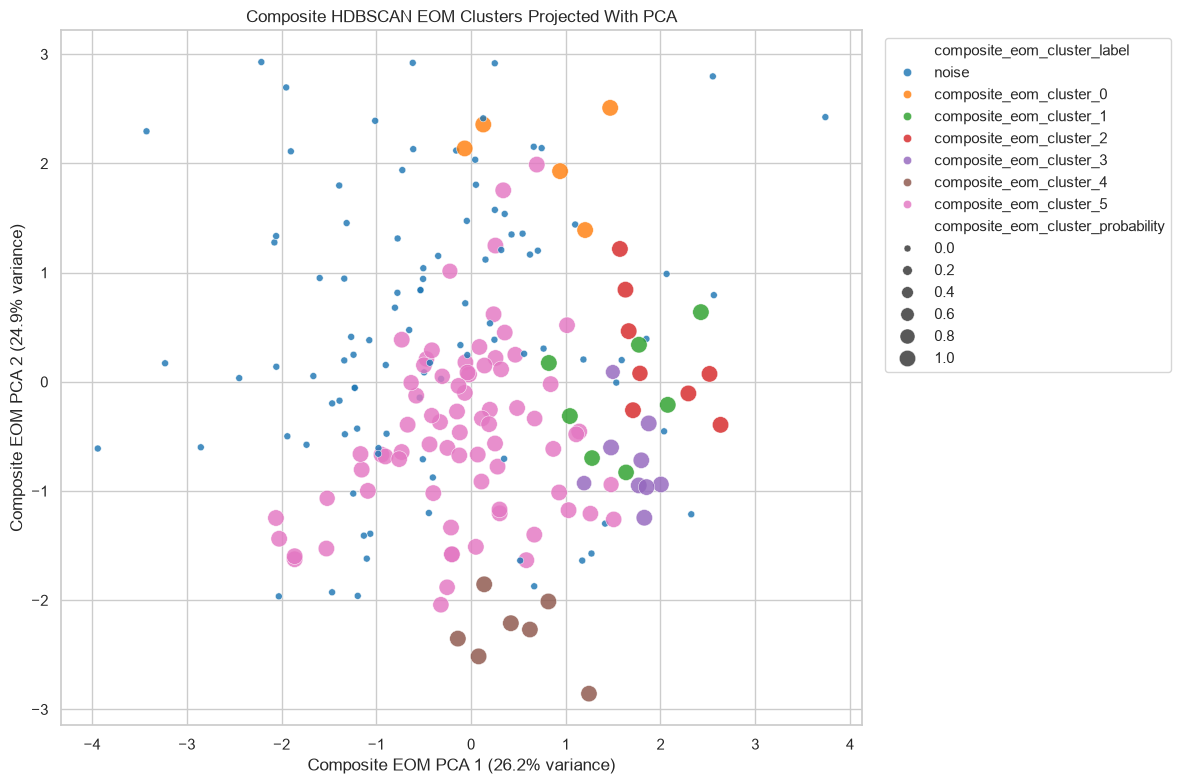

In [29]:
composite_eom_pca = PCA(n_components=2, random_state=42)
composite_eom_pca_components = composite_eom_pca.fit_transform(X_composite_scaled)
composite_eom_input["composite_eom_pca_1"] = composite_eom_pca_components[:, 0]
composite_eom_input["composite_eom_pca_2"] = composite_eom_pca_components[:, 1]

composite_eom_plot_data = composite_eom_input.copy()
composite_eom_plot_data["composite_eom_cluster_label"] = pd.Categorical(
    composite_eom_plot_data["composite_eom_cluster_label"],
    categories=["noise"] + sorted(
        [label for label in composite_eom_plot_data["composite_eom_cluster_label"].unique() if label != "noise"],
        key=lambda value: int(value.split("_")[-1]),
    ),
    ordered=True,
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=composite_eom_plot_data,
    x="composite_eom_pca_1",
    y="composite_eom_pca_2",
    hue="composite_eom_cluster_label",
    size="composite_eom_cluster_probability",
    sizes=(25, 140),
    alpha=0.82,
    palette="tab10",
)
plt.title("Composite HDBSCAN EOM Clusters Projected With PCA")
plt.xlabel(f"Composite EOM PCA 1 ({composite_eom_pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Composite EOM PCA 2 ({composite_eom_pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Composite-Feature EOM Cluster Profiles

These tables mirror the composite leaf profiles, but summarize clusters selected with `eom`. They help determine whether composite dimensions produce clearer broader neighborhoods under a more stability-oriented selection method.

In [30]:
composite_eom_clustered = composite_eom_input[composite_eom_input["composite_eom_cluster"] != -1].copy()
composite_eom_global_means = composite_eom_input[COMPOSITE_FEATURE_COLUMNS].mean()
composite_eom_global_stds = composite_eom_input[COMPOSITE_FEATURE_COLUMNS].std(ddof=0).replace(0, np.nan)

if composite_eom_clustered.empty:
    print("No non-noise composite eom clusters found. Try lowering COMPOSITE_EOM_MIN_CLUSTER_SIZE or COMPOSITE_EOM_MIN_SAMPLES.")
    composite_eom_cluster_profile = pd.DataFrame(
        columns=[
            "composite_eom_cluster",
            "tracks",
            "avg_probability",
            "avg_outlier_score",
            "avg_match_score",
            "playlists",
            "artists",
        ] + [f"avg_{column}" for column in COMPOSITE_FEATURE_COLUMNS]
    )
    composite_eom_cluster_signatures = pd.DataFrame(
        columns=["composite_eom_cluster", "tracks", "top_positive_features", "top_negative_features"]
    )
else:
    composite_eom_cluster_profile = (
        composite_eom_clustered
        .groupby("composite_eom_cluster")
        .agg(
            tracks=("rekordbox_track_id", "count"),
            avg_probability=("composite_eom_cluster_probability", "mean"),
            avg_outlier_score=("composite_eom_outlier_score", "mean"),
            avg_match_score=("match_score", "mean"),
            playlists=("playlist_name", "nunique"),
            artists=("rekordbox_artist", "nunique"),
            **{f"avg_{column}": (column, "mean") for column in COMPOSITE_FEATURE_COLUMNS},
        )
        .reset_index()
        .sort_values(["tracks", "avg_probability"], ascending=[False, False])
    )

    composite_eom_signature_rows = []
    for composite_eom_cluster_id, frame in composite_eom_clustered.groupby("composite_eom_cluster"):
        composite_eom_deltas = ((frame[COMPOSITE_FEATURE_COLUMNS].mean() - composite_eom_global_means) / composite_eom_global_stds).sort_values(
            key=np.abs,
            ascending=False,
        )
        composite_eom_signature_rows.append(
            {
                "composite_eom_cluster": composite_eom_cluster_id,
                "tracks": len(frame),
                "top_positive_features": ", ".join(
                    f"{feature} (+{value:.2f}sd)" for feature, value in composite_eom_deltas[composite_eom_deltas > 0].head(4).items()
                ),
                "top_negative_features": ", ".join(
                    f"{feature} ({value:.2f}sd)" for feature, value in composite_eom_deltas[composite_eom_deltas < 0].head(4).items()
                ),
            }
        )
    composite_eom_cluster_signatures = pd.DataFrame(composite_eom_signature_rows).sort_values("tracks", ascending=False)

display(composite_eom_cluster_profile)
display(composite_eom_cluster_signatures)

,composite_eom_cluster,tracks,avg_probability,avg_outlier_score,avg_match_score,playlists,artists,avg_bpm,avg_popularity,avg_intensity,avg_warmth,avg_mixability,avg_vocal_presence
5,5,74,0.990838,0.172845,0.902169,1,57,129.098270,51.608108,0.841800,0.235541,0.691775,0.213622
3,3,9,0.950347,0.049653,0.970156,1,5,125.670222,47.333333,0.680133,0.163963,0.819148,0.081667
2,2,8,0.991458,0.008542,0.905575,1,8,124.762250,52.750000,0.790400,0.360458,0.827417,0.122188
4,4,7,0.994790,0.005210,0.965171,1,7,151.586286,53.571429,0.911314,0.142905,0.758810,0.121143
1,1,7,0.991416,0.008584,0.958986,1,6,127.995571,14.142857,0.817029,0.322143,0.784238,0.103071
0,0,5,1.000000,0.000000,0.960640,1,5,116.030400,58.400000,0.592920,0.395133,0.728067,0.247200


,composite_eom_cluster,tracks,top_positive_features,top_negative_features
5,5,74,"intensity (+0.52sd), popularity (+0.28sd), bpm...","warmth (-0.20sd), vocal_presence (-0.07sd), mi..."
3,3,9,"mixability (+1.42sd), popularity (+0.08sd)","vocal_presence (-1.35sd), warmth (-1.00sd), in..."
2,2,8,"mixability (+1.51sd), warmth (+1.20sd), popula...","vocal_presence (-0.96sd), bpm (-0.15sd)"
1,1,7,"mixability (+1.02sd), warmth (+0.77sd), intens...","popularity (-1.52sd), vocal_presence (-1.14sd)"
4,4,7,"bpm (+1.23sd), intensity (+1.08sd), mixability...","warmth (-1.24sd), vocal_presence (-0.97sd)"
0,0,5,"warmth (+1.59sd), popularity (+0.61sd), mixabi...","intensity (-1.49sd), bpm (-0.60sd)"


## Composite-Feature EOM Representative Tracks

Use these representatives, boundary tracks, and noise tracks to evaluate whether `eom` creates musically useful broad composite clusters.

In [31]:
composite_eom_representative_columns = [
    "composite_eom_cluster",
    "composite_eom_cluster_probability",
    "composite_eom_outlier_score",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "bpm",
    "popularity",
    "intensity",
    "warmth",
    "mixability",
    "vocal_presence",
    "spotify_url",
]

composite_eom_representative_tracks = (
    composite_eom_clustered
    .sort_values(["composite_eom_cluster", "composite_eom_cluster_probability", "composite_eom_outlier_score"], ascending=[True, False, True])
    .groupby("composite_eom_cluster", group_keys=False)
    .head(10)
    [composite_eom_representative_columns]
)
display(composite_eom_representative_tracks)

composite_eom_boundary_tracks = (
    composite_eom_clustered
    .sort_values(["composite_eom_cluster", "composite_eom_cluster_probability", "composite_eom_outlier_score"], ascending=[True, True, False])
    .groupby("composite_eom_cluster", group_keys=False)
    .head(5)
    [composite_eom_representative_columns]
)
display(composite_eom_boundary_tracks)

composite_eom_noise_tracks = (
    composite_eom_input[composite_eom_input["composite_eom_cluster"] == -1]
    .sort_values("composite_eom_outlier_score", ascending=False)
    [composite_eom_representative_columns]
)
print(f"Composite eom noise tracks: {len(composite_eom_noise_tracks):,}")
display(composite_eom_noise_tracks.head(30))

,composite_eom_cluster,composite_eom_cluster_probability,composite_eom_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,intensity,warmth,mixability,vocal_presence,spotify_url
12,0,1.000000,0.000000,faking it [explicit],calvin harris feat. kehlani & lil yachty,Faking It (feat. Kehlani & Lil Yachty),"Calvin Harris, Kehlani, Lil Yachty, Funk Wav",Z,120.034,59,0.6002,0.426667,0.683333,0.2920,https://open.spotify.com/track/0pJPdSVti6cTM1Q...
121,0,1.000000,0.000000,10count,rym,10count,Rym,Z,107.020,64,0.5272,0.406000,0.784333,0.2320,https://open.spotify.com/track/06dAXZd6k4eAnco...
125,0,1.000000,0.000000,faded (original mix),zhu,Faded,ZHU,Z,124.979,59,0.5788,0.344000,0.781333,0.2040,https://open.spotify.com/track/2GQEM9JuHu30sGF...
140,0,1.000000,0.000000,i wanna be your lover (original mix),prince,I Wanna Be Your Lover,Prince,Z,114.832,58,0.5890,0.384667,0.734000,0.2190,https://open.spotify.com/track/2XLAzm8bMDSI7Mh...
174,0,1.000000,0.000000,weight on my shoulders [explicit],rod wave,Weight On My Shoulders,Rod Wave,Z,113.287,52,0.6694,0.414333,0.657333,0.2890,https://open.spotify.com/track/5PVHJQ1iuQZ7srM...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.7982,0.336000,0.714667,0.1340,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.7768,0.327667,0.816333,0.0625,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.7788,0.350333,0.805333,0.1190,https://open.spotify.com/track/5vu69csqeUJheoQ...
152,1,1.000000,0.000000,gimme some keys (original mix),matroda,Gimme Some Keys,Matroda,Z,124.992,12,0.7350,0.390667,0.836333,0.0780,https://open.spotify.com/track/5qiMjMnVdbwfifs...
185,1,1.000000,0.000000,lose my breath (kevin mckay extended remix),moreno pezzolato,Lose My Breath - Kevin McKay Extended Remix,"Moreno Pezzolato, Kevin McKay",Z,123.998,10,0.8056,0.269333,0.725333,0.0970,https://open.spotify.com/track/2WRTX5EAG8LX2AL...


,composite_eom_cluster,composite_eom_cluster_probability,composite_eom_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,intensity,warmth,mixability,vocal_presence,spotify_url
12,0,1.000000,0.000000,faking it [explicit],calvin harris feat. kehlani & lil yachty,Faking It (feat. Kehlani & Lil Yachty),"Calvin Harris, Kehlani, Lil Yachty, Funk Wav",Z,120.034,59,0.6002,0.426667,0.683333,0.2920,https://open.spotify.com/track/0pJPdSVti6cTM1Q...
121,0,1.000000,0.000000,10count,rym,10count,Rym,Z,107.020,64,0.5272,0.406000,0.784333,0.2320,https://open.spotify.com/track/06dAXZd6k4eAnco...
125,0,1.000000,0.000000,faded (original mix),zhu,Faded,ZHU,Z,124.979,59,0.5788,0.344000,0.781333,0.2040,https://open.spotify.com/track/2GQEM9JuHu30sGF...
140,0,1.000000,0.000000,i wanna be your lover (original mix),prince,I Wanna Be Your Lover,Prince,Z,114.832,58,0.5890,0.384667,0.734000,0.2190,https://open.spotify.com/track/2XLAzm8bMDSI7Mh...
174,0,1.000000,0.000000,weight on my shoulders [explicit],rod wave,Weight On My Shoulders,Rod Wave,Z,113.287,52,0.6694,0.414333,0.657333,0.2890,https://open.spotify.com/track/5PVHJQ1iuQZ7srM...
71,1,0.969957,0.030043,soundboy (extended mix),san pacho,Soundboy,San Pacho,Z,127.963,26,0.9176,0.287000,0.798000,0.1470,https://open.spotify.com/track/5RU33jajJPKSXfq...
179,1,0.969957,0.030043,like i like it (original mix),mau p,Like I Like It,Mau P,Z,128.000,24,0.9072,0.294000,0.793667,0.0840,https://open.spotify.com/track/6vLKVWEuOCQAWEa...
32,1,1.000000,0.000000,twostep (extended mix),riordan,TWOSTEP,Riordan,Z,132.009,0,0.7982,0.336000,0.714667,0.1340,https://open.spotify.com/track/1Gm9mRYaqU7VpJB...
38,1,1.000000,0.000000,tesla (extended mix),mau p,TESLA,Mau P,Z,132.014,27,0.7768,0.327667,0.816333,0.0625,https://open.spotify.com/track/6qJhrI2BMuA8qHc...
107,1,1.000000,0.000000,la noche (extended mix),"chris lake, skrillex, anita b queen",LA NOCHE,"Chris Lake, Skrillex, ANITA B QUEEN",Z,126.993,0,0.7788,0.350333,0.805333,0.1190,https://open.spotify.com/track/5vu69csqeUJheoQ...


Composite eom noise tracks: 99


,composite_eom_cluster,composite_eom_cluster_probability,composite_eom_outlier_score,rekordbox_title,rekordbox_artist,spotify_title,spotify_artist_names,playlist_name,bpm,popularity,intensity,warmth,mixability,vocal_presence,spotify_url
23,-1,0.0,0.792501,calypso (original mix),"nxsty, ero808",Calypso,Natsu,Z,90.018,23,0.3598,0.366000,0.755667,0.0430,https://open.spotify.com/track/37u3HPOkVWbSMAG...
145,-1,0.0,0.766710,switch,"coco palmer, deadfreshfruit",SWITCH,Eatin' & Zachor,Z,75.516,0,0.5178,0.213000,0.464000,0.3855,https://open.spotify.com/track/6EjXU1XgECsr6LG...
151,-1,0.0,0.743851,el baile,heynegaard & lvga,El Baile,"HP. Hoeger, M. Lackmaier",Z,127.015,27,0.4346,0.494333,0.921667,0.0500,https://open.spotify.com/track/54x5G6IhYHNfUT8...
69,-1,0.0,0.738063,better than i've ever been (original mix),griz,Better Than I've Ever Been,GRiZ,Z,103.862,12,0.8722,0.148667,0.482333,0.3265,https://open.spotify.com/track/2wZAqY6Ni3485xD...
56,-1,0.0,0.727748,mercy,"kanye west ft. big sean, pusha t & two chainz",Mercy,"Kanye West, Big Sean, Pusha T, 2 Chainz",Z,139.993,70,0.5374,0.293667,0.485333,0.5250,https://open.spotify.com/track/4qikXelSRKvoCqF...
88,-1,0.0,0.723673,pushinn (original mix),nikko,PUSHINN,nikko,Z,134.007,0,0.9562,0.127667,0.810333,0.1825,https://open.spotify.com/track/3afe2BTqwgrwrLo...
7,-1,0.0,0.716989,lite spots (original mix),kaytranada,LITE SPOTS,KAYTRANADA,Z,120.461,52,0.6342,0.262000,0.685000,0.5630,https://open.spotify.com/track/3Fc7k96EGOGiJBM...
188,-1,0.0,0.716989,push it (eastmix),dave east,Push It - EASTMIX,Dave East,Z,127.950,26,0.5848,0.334667,0.649333,0.5440,https://open.spotify.com/track/4eswve9pQufeesx...
36,-1,0.0,0.716099,witching hour (original mix),rezz,Witching Hour,Rezz,Z,179.967,1,0.6372,0.216000,0.653000,0.2605,https://open.spotify.com/track/3ePl4Dn8C7irkmq...
175,-1,0.0,0.716099,infraliminal (isabelle's version),"deadmau5, rezz, rezzmau5",Infraliminal,"REZZMAU5, deadmau5, Rezz",Z,180.034,24,0.4784,0.175000,0.652333,0.2630,https://open.spotify.com/track/0Z38r2LjrMNGDKI...


## Export Composite-Feature EOM Assignments

These exports use separate filenames so the composite `leaf` outputs remain unchanged.

In [32]:
composite_eom_assignment_columns = [
    "rekordbox_track_id",
    "spotify_track_id",
    "composite_cluster",
    "composite_cluster_label",
    "composite_cluster_probability",
    "composite_outlier_score",
    "composite_eom_cluster",
    "composite_eom_cluster_label",
    "composite_eom_cluster_probability",
    "composite_eom_outlier_score",
    "composite_eom_pca_1",
    "composite_eom_pca_2",
    "rekordbox_title",
    "rekordbox_artist",
    "spotify_title",
    "spotify_artist_names",
    "playlist_name",
    "match_score",
    "spotify_url",
] + COMPOSITE_FEATURE_COLUMNS + FEATURE_COLUMNS

composite_eom_assignments_path = EXPORT_DIR / "hdbscan_composite_eom_track_clusters.csv"
composite_eom_profile_path = EXPORT_DIR / "hdbscan_composite_eom_cluster_profiles.csv"
composite_eom_signatures_path = EXPORT_DIR / "hdbscan_composite_eom_cluster_signatures.csv"

composite_eom_input[composite_eom_assignment_columns].to_csv(composite_eom_assignments_path, index=False)
composite_eom_cluster_profile.to_csv(composite_eom_profile_path, index=False)
composite_eom_cluster_signatures.to_csv(composite_eom_signatures_path, index=False)

print(f"Wrote {composite_eom_assignments_path}")
print(f"Wrote {composite_eom_profile_path}")
print(f"Wrote {composite_eom_signatures_path}")

Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_composite_eom_track_clusters.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_composite_eom_cluster_profiles.csv
Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_composite_eom_cluster_signatures.csv


## Compare Cluster Selection Experiments

This final comparison summarizes all four experiment paths: full-feature leaf, full-feature eom, composite-feature leaf, and composite-feature eom. Use it to decide whether feature representation or cluster selection method changes the number of usable style neighborhoods more.

In [33]:
selection_method_summary = pd.DataFrame(
    [
        {
            "model": "full_feature_leaf",
            "feature_representation": "full",
            "cluster_selection_method": CLUSTER_SELECTION_METHOD,
            "features": len(FEATURE_COLUMNS),
            "clusters": cluster_count,
            "noise_tracks": noise_count,
            "noise_rate": noise_rate,
        },
        {
            "model": "full_feature_eom",
            "feature_representation": "full",
            "cluster_selection_method": FULL_EOM_CLUSTER_SELECTION_METHOD,
            "features": len(FEATURE_COLUMNS),
            "clusters": full_eom_cluster_count,
            "noise_tracks": full_eom_noise_count,
            "noise_rate": full_eom_noise_rate,
        },
        {
            "model": "composite_feature_leaf",
            "feature_representation": "composite",
            "cluster_selection_method": COMPOSITE_CLUSTER_SELECTION_METHOD,
            "features": len(COMPOSITE_FEATURE_COLUMNS),
            "clusters": composite_cluster_count,
            "noise_tracks": composite_noise_count,
            "noise_rate": composite_noise_rate,
        },
        {
            "model": "composite_feature_eom",
            "feature_representation": "composite",
            "cluster_selection_method": COMPOSITE_EOM_CLUSTER_SELECTION_METHOD,
            "features": len(COMPOSITE_FEATURE_COLUMNS),
            "clusters": composite_eom_cluster_count,
            "noise_tracks": composite_eom_noise_count,
            "noise_rate": composite_eom_noise_rate,
        },
    ]
)

display(selection_method_summary)

selection_method_summary_path = EXPORT_DIR / "hdbscan_cluster_selection_method_comparison.csv"
selection_method_summary.to_csv(selection_method_summary_path, index=False)
print(f"Wrote {selection_method_summary_path}")

,model,feature_representation,cluster_selection_method,features,clusters,noise_tracks,noise_rate
0,full_feature_leaf,full,leaf,15,9,128,0.612440
1,full_feature_eom,full,eom,15,6,98,0.468900
2,composite_feature_leaf,composite,leaf,6,10,134,0.641148
3,composite_feature_eom,composite,eom,6,6,99,0.473684


Wrote /Users/zacurbiztondo/dj-library-helper/data/exports/hdbscan_cluster_selection_method_comparison.csv


## Interpretation Notes

Use all clustering passes as exploratory structure, not a final taxonomy. The full-feature models are more granular about every analysis signal; the composite-feature models are more deliberate about preventing related features from overpowering the distance calculation. The `leaf` experiments tend to expose smaller local pockets, while the `eom` experiments can reveal broader stable neighborhoods.

Recommended next steps:

1. Review representative and boundary tracks for each full-feature and composite cluster, then assign human-readable style labels.
2. Use the cluster comparison tables to identify stable neighborhoods that appear across feature representations and selection methods.
3. Tune `MIN_CLUSTER_SIZE`, `MIN_SAMPLES`, and cluster selection method for both feature representations to balance broad style neighborhoods against smaller niche pockets.
4. Re-run after adding unmatched-track handling, key/harmony features, genres, lyrics, and release-date features.
5. Use high-probability tracks as style-profile seeds and noise/boundary tracks as candidates for cluster expansion and recommendation edge cases.